In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sbn

In [5]:
df = pd.read_csv("../data/upi_transactions_2024.csv")

In [6]:
df.head()

,transaction id,timestamp,transaction type,merchant_category,amount (INR),transaction_status,sender_age_group,receiver_age_group,sender_state,sender_bank,receiver_bank,device_type,network_type,fraud_flag,hour_of_day,day_of_week,is_weekend
0,TXN0000000001,2024-10-08 15:17:28,P2P,Entertainment,868,SUCCESS,26-35,18-25,Delhi,Axis,SBI,Android,4G,0,15,Tuesday,0
1,TXN0000000002,2024-04-11 06:56:00,P2M,Grocery,1011,SUCCESS,26-35,26-35,Uttar Pradesh,ICICI,Axis,iOS,4G,0,6,Thursday,0
2,TXN0000000003,2024-04-02 13:27:18,P2P,Grocery,477,SUCCESS,26-35,36-45,Karnataka,Yes Bank,PNB,Android,4G,0,13,Tuesday,0
3,TXN0000000004,2024-01-07 10:09:17,P2P,Fuel,2784,SUCCESS,26-35,26-35,Delhi,ICICI,PNB,Android,5G,0,10,Sunday,1
4,TXN0000000005,2024-01-23 19:04:23,P2P,Shopping,990,SUCCESS,26-35,18-25,Delhi,Axis,Yes Bank,iOS,WiFi,0,19,Tuesday,0


In [7]:
df.shape

(250000, 17)

In [8]:
df.columns

Index(['transaction id', 'timestamp', 'transaction type', 'merchant_category',
       'amount (INR)', 'transaction_status', 'sender_age_group',
       'receiver_age_group', 'sender_state', 'sender_bank', 'receiver_bank',
       'device_type', 'network_type', 'fraud_flag', 'hour_of_day',
       'day_of_week', 'is_weekend'],
      dtype='object')

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 17 columns):
 #   Column              Non-Null Count   Dtype 
---  ------              --------------   ----- 
 0   transaction id      250000 non-null  object
 1   timestamp           250000 non-null  object
 2   transaction type    250000 non-null  object
 3   merchant_category   250000 non-null  object
 4   amount (INR)        250000 non-null  int64 
 5   transaction_status  250000 non-null  object
 6   sender_age_group    250000 non-null  object
 7   receiver_age_group  250000 non-null  object
 8   sender_state        250000 non-null  object
 9   sender_bank         250000 non-null  object
 10  receiver_bank       250000 non-null  object
 11  device_type         250000 non-null  object
 12  network_type        250000 non-null  object
 13  fraud_flag          250000 non-null  int64 
 14  hour_of_day         250000 non-null  int64 
 15  day_of_week         250000 non-null  object
 16  is

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 17 columns):
 #   Column              Non-Null Count   Dtype 
---  ------              --------------   ----- 
 0   transaction id      250000 non-null  object
 1   timestamp           250000 non-null  object
 2   transaction type    250000 non-null  object
 3   merchant_category   250000 non-null  object
 4   amount (INR)        250000 non-null  int64 
 5   transaction_status  250000 non-null  object
 6   sender_age_group    250000 non-null  object
 7   receiver_age_group  250000 non-null  object
 8   sender_state        250000 non-null  object
 9   sender_bank         250000 non-null  object
 10  receiver_bank       250000 non-null  object
 11  device_type         250000 non-null  object
 12  network_type        250000 non-null  object
 13  fraud_flag          250000 non-null  int64 
 14  hour_of_day         250000 non-null  int64 
 15  day_of_week         250000 non-null  object
 16  is

In [11]:
df.isnull().sum()

transaction id        0
timestamp             0
transaction type      0
merchant_category     0
amount (INR)          0
transaction_status    0
sender_age_group      0
receiver_age_group    0
sender_state          0
sender_bank           0
receiver_bank         0
device_type           0
network_type          0
fraud_flag            0
hour_of_day           0
day_of_week           0
is_weekend            0
dtype: int64

In [12]:
df.columns.tolist()

['transaction id',
 'timestamp',
 'transaction type',
 'merchant_category',
 'amount (INR)',
 'transaction_status',
 'sender_age_group',
 'receiver_age_group',
 'sender_state',
 'sender_bank',
 'receiver_bank',
 'device_type',
 'network_type',
 'fraud_flag',
 'hour_of_day',
 'day_of_week',
 'is_weekend']

In [13]:
df.head()

,transaction id,timestamp,transaction type,merchant_category,amount (INR),transaction_status,sender_age_group,receiver_age_group,sender_state,sender_bank,receiver_bank,device_type,network_type,fraud_flag,hour_of_day,day_of_week,is_weekend
0,TXN0000000001,2024-10-08 15:17:28,P2P,Entertainment,868,SUCCESS,26-35,18-25,Delhi,Axis,SBI,Android,4G,0,15,Tuesday,0
1,TXN0000000002,2024-04-11 06:56:00,P2M,Grocery,1011,SUCCESS,26-35,26-35,Uttar Pradesh,ICICI,Axis,iOS,4G,0,6,Thursday,0
2,TXN0000000003,2024-04-02 13:27:18,P2P,Grocery,477,SUCCESS,26-35,36-45,Karnataka,Yes Bank,PNB,Android,4G,0,13,Tuesday,0
3,TXN0000000004,2024-01-07 10:09:17,P2P,Fuel,2784,SUCCESS,26-35,26-35,Delhi,ICICI,PNB,Android,5G,0,10,Sunday,1
4,TXN0000000005,2024-01-23 19:04:23,P2P,Shopping,990,SUCCESS,26-35,18-25,Delhi,Axis,Yes Bank,iOS,WiFi,0,19,Tuesday,0


In [14]:
df["fraud_flag"].value_counts()

fraud_flag
0    249520
1       480
Name: count, dtype: int64

In [15]:
df["fraud_flag"].value_counts(normalize=True) * 100

fraud_flag
0    99.808
1     0.192
Name: proportion, dtype: float64

In [16]:
df[df["fraud_flag"]==1].head()

,transaction id,timestamp,transaction type,merchant_category,amount (INR),transaction_status,sender_age_group,receiver_age_group,sender_state,sender_bank,receiver_bank,device_type,network_type,fraud_flag,hour_of_day,day_of_week,is_weekend
740,TXN0000000741,2024-10-30 17:37:20,Recharge,Healthcare,361,SUCCESS,18-25,18-25,Karnataka,SBI,ICICI,Android,5G,1,17,Wednesday,0
1228,TXN0000001229,2024-06-22 00:21:52,P2P,Fuel,479,SUCCESS,26-35,36-45,Karnataka,SBI,HDFC,iOS,4G,1,0,Saturday,1
2777,TXN0000002778,2024-06-12 19:46:25,P2P,Food,162,SUCCESS,18-25,36-45,Gujarat,PNB,ICICI,iOS,4G,1,19,Wednesday,0
3761,TXN0000003762,2024-01-30 19:57:42,P2M,Transport,754,SUCCESS,26-35,36-45,Karnataka,ICICI,SBI,Android,5G,1,19,Tuesday,0
3962,TXN0000003963,2024-11-28 21:36:02,P2P,Healthcare,402,SUCCESS,26-35,36-45,Maharashtra,Yes Bank,Kotak,Web,4G,1,21,Thursday,0


In [17]:
df[df["fraud_flag"] == 1]["transaction type"].value_counts()

transaction type
P2P             206
P2M             167
Bill Payment     77
Recharge         30
Name: count, dtype: int64

In [18]:
df[df["fraud_flag"]==1]["merchant_category"].value_counts()

merchant_category
Grocery          94
Food             73
Shopping         62
Other            50
Fuel             48
Transport        43
Entertainment    40
Utilities        33
Healthcare       21
Education        16
Name: count, dtype: int64

In [19]:
df.groupby("fraud_flag")["amount (INR)"].describe()

,count,mean,std,min,25%,50%,75%,max
fraud_flag,,,,,,,,
0,249520.0,1311.395391,1847.210565,10.0,288.0,629.0,1596.0,42099.0
1,480.0,1499.231250,2240.707939,28.0,260.0,618.5,1673.5,17718.0


In [20]:
df.duplicated().sum()

np.int64(0)

In [21]:
df["transaction id"].duplicated().sum()

np.int64(0)

In [22]:
df.isnull().sum().sum()

np.int64(0)

In [23]:
df.dtypes

transaction id        object
timestamp             object
transaction type      object
merchant_category     object
amount (INR)           int64
transaction_status    object
sender_age_group      object
receiver_age_group    object
sender_state          object
sender_bank           object
receiver_bank         object
device_type           object
network_type          object
fraud_flag             int64
hour_of_day            int64
day_of_week           object
is_weekend             int64
dtype: object

In [24]:
pd.crosstab(
    df["transaction_status"],
    df["fraud_flag"],
    normalize="index"
)

fraud_flag,0,1
transaction_status,,
FAILED,0.998303,0.001697
SUCCESS,0.998068,0.001932


In [25]:
pd.crosstab(
    df["transaction type"],
    df["fraud_flag"],
    normalize="index"
)

fraud_flag,0,1
transaction type,,
Bill Payment,0.997939,0.002061
P2M,0.998095,0.001905
P2P,0.998168,0.001832
Recharge,0.997605,0.002395


In [26]:
df["transaction type"].value_counts()

transaction type
P2P             112445
P2M              87660
Bill Payment     37368
Recharge         12527
Name: count, dtype: int64

In [27]:
df["merchant_category"].value_counts()

merchant_category
Grocery          49966
Food             37464
Shopping         29872
Fuel             25063
Other            24828
Utilities        22338
Transport        20105
Entertainment    20103
Healthcare       12663
Education         7598
Name: count, dtype: int64

In [28]:
df["device_type"].value_counts()

device_type
Android    187777
iOS         49613
Web         12610
Name: count, dtype: int64

In [29]:
df.groupby("transaction type")["fraud_flag"].mean() * 100

transaction type
Bill Payment    0.206059
P2M             0.190509
P2P             0.183201
Recharge        0.239483
Name: fraud_flag, dtype: float64

In [30]:
df.groupby("device_type")["fraud_flag"].mean() * 100

device_type
Android    0.193847
Web        0.206186
iOS        0.181404
Name: fraud_flag, dtype: float64

In [31]:
df.groupby("merchant_category")["fraud_flag"].mean().sort_values(ascending=False) * 100

merchant_category
Transport        0.213877
Education        0.210582
Shopping         0.207552
Other            0.201386
Entertainment    0.198975
Food             0.194854
Fuel             0.191517
Grocery          0.188128
Healthcare       0.165837
Utilities        0.147730
Name: fraud_flag, dtype: float64

In [32]:
df.groupby("fraud_flag")["amount (INR)"].describe()

,count,mean,std,min,25%,50%,75%,max
fraud_flag,,,,,,,,
0,249520.0,1311.395391,1847.210565,10.0,288.0,629.0,1596.0,42099.0
1,480.0,1499.231250,2240.707939,28.0,260.0,618.5,1673.5,17718.0


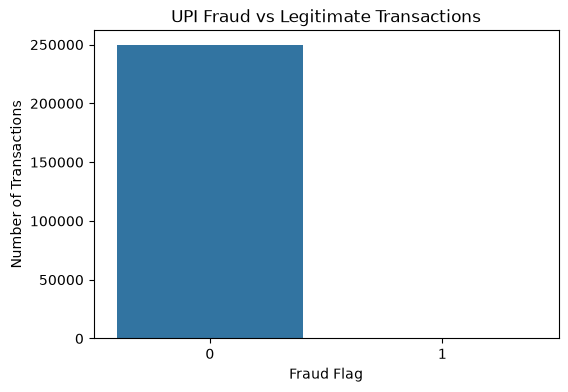

In [33]:
plt.figure(figsize=(6, 4))

sbn.countplot(data=df, x="fraud_flag")

plt.title("UPI Fraud vs Legitimate Transactions")
plt.xlabel("Fraud Flag")
plt.ylabel("Number of Transactions")

plt.show()

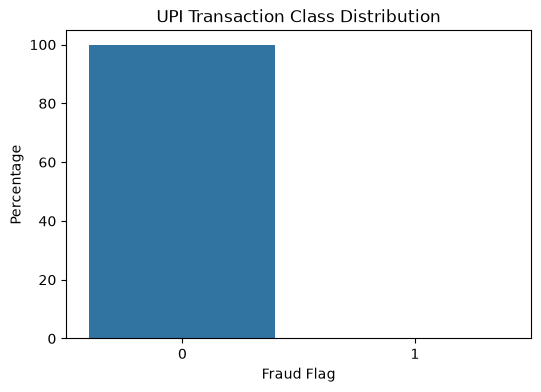

In [34]:
fraud_percent = df["fraud_flag"].value_counts(normalize=True) * 100

plt.figure(figsize=(6, 4))

sbn.barplot(
    x=fraud_percent.index,
    y=fraud_percent.values
)

plt.title("UPI Transaction Class Distribution")
plt.xlabel("Fraud Flag")
plt.ylabel("Percentage")

plt.show()

In [35]:
df["hour_of_day"].value_counts().sort_index()

hour_of_day
0      3388
1      2244
2      1685
3      1314
4      1247
5      1742
6      3501
7      5630
8      8349
9     10450
10    13904
11    16328
12    17516
13    15038
14    11472
15    12624
16    13992
17    18340
18    20064
19    21232
20    18506
21    16253
22     9364
23     5817
Name: count, dtype: int64

In [36]:
fraud_by_hour = df.groupby("hour_of_day")["fraud_flag"].mean() * 100
fraud_by_hour

hour_of_day
0     0.236128
1     0.267380
2     0.178042
3     0.304414
4     0.080192
5     0.057405
6     0.142816
7     0.230906
8     0.215595
9     0.191388
10    0.143843
11    0.165360
12    0.171272
13    0.166246
14    0.183054
15    0.253485
16    0.221555
17    0.201745
18    0.154506
19    0.202524
20    0.199935
21    0.215345
22    0.245622
23    0.154719
Name: fraud_flag, dtype: float64

In [37]:
df["day_of_week"].value_counts()

day_of_week
Monday       36495
Sunday       36003
Wednesday    35700
Tuesday      35540
Friday       35496
Thursday     35432
Saturday     35334
Name: count, dtype: int64

In [38]:
fraud_by_day = df.groupby("day_of_week")["fraud_flag"].mean() * 100

fraud_by_day

day_of_week
Friday       0.171850
Monday       0.194547
Saturday     0.192449
Sunday       0.208316
Thursday     0.203206
Tuesday      0.163196
Wednesday    0.210084
Name: fraud_flag, dtype: float64

In [39]:
df.groupby("is_weekend")["fraud_flag"].mean() * 100

is_weekend
0    0.188623
1    0.200457
Name: fraud_flag, dtype: float64

In [40]:
df["timestamp"].head()

0    2024-10-08 15:17:28
1    2024-04-11 06:56:00
2    2024-04-02 13:27:18
3    2024-01-07 10:09:17
4    2024-01-23 19:04:23
Name: timestamp, dtype: object

In [41]:
df["timestamp"].min(), df["timestamp"].max()

('2024-01-01 00:05:10', '2024-12-30 23:55:40')

In [42]:
df["timestamp"].nunique()

248610

In [43]:
df["timestamp_dt"] = pd.to_datetime(df["timestamp"])

df["calculated_hour"] = df["timestamp_dt"].dt.hour

(df["calculated_hour"] == df["hour_of_day"]).mean()

np.float64(1.0)

In [44]:
df["calculated_day"] = df["timestamp_dt"].dt.day_name()

(df["calculated_day"] == df["day_of_week"]).mean()

np.float64(1.0)

In [45]:
df.nunique().sort_values()

transaction_status         2
fraud_flag                 2
is_weekend                 2
device_type                3
network_type               4
transaction type           4
receiver_age_group         5
sender_age_group           5
calculated_day             7
day_of_week                7
sender_bank                8
receiver_bank              8
sender_state              10
merchant_category         10
hour_of_day               24
calculated_hour           24
amount (INR)           10355
timestamp             248610
timestamp_dt          248610
transaction id        250000
dtype: int64

In [46]:
df.drop(
    columns=["timestamp_dt", "calculated_hour", "calculated_day"],
    inplace=True
)

In [47]:
df.columns

Index(['transaction id', 'timestamp', 'transaction type', 'merchant_category',
       'amount (INR)', 'transaction_status', 'sender_age_group',
       'receiver_age_group', 'sender_state', 'sender_bank', 'receiver_bank',
       'device_type', 'network_type', 'fraud_flag', 'hour_of_day',
       'day_of_week', 'is_weekend'],
      dtype='object')

In [48]:
X = df.drop(
    columns=["fraud_flag","transaction id", "timestamp"]
)
y=df["fraud_flag"]

In [49]:
X.shape, y.shape

((250000, 14), (250000,))

In [50]:
X.head()

,transaction type,merchant_category,amount (INR),transaction_status,sender_age_group,receiver_age_group,sender_state,sender_bank,receiver_bank,device_type,network_type,hour_of_day,day_of_week,is_weekend
0,P2P,Entertainment,868,SUCCESS,26-35,18-25,Delhi,Axis,SBI,Android,4G,15,Tuesday,0
1,P2M,Grocery,1011,SUCCESS,26-35,26-35,Uttar Pradesh,ICICI,Axis,iOS,4G,6,Thursday,0
2,P2P,Grocery,477,SUCCESS,26-35,36-45,Karnataka,Yes Bank,PNB,Android,4G,13,Tuesday,0
3,P2P,Fuel,2784,SUCCESS,26-35,26-35,Delhi,ICICI,PNB,Android,5G,10,Sunday,1
4,P2P,Shopping,990,SUCCESS,26-35,18-25,Delhi,Axis,Yes Bank,iOS,WiFi,19,Tuesday,0


In [51]:
df.groupby("sender_age_group")["fraud_flag"].agg(
    total="count",
    frauds="sum",
    fraud_rate="mean"
)

,total,frauds,fraud_rate
sender_age_group,,,
18-25,62345,143,0.002294
26-35,87432,163,0.001864
36-45,62873,116,0.001845
46-55,24841,31,0.001248
56+,12509,27,0.002158


In [52]:
age_bias = df.groupby("sender_age_group")["fraud_flag"].agg(
    total="count",
    frauds="sum",
    fraud_rate="mean"
)

age_bias["fraud_rate"] *= 100

age_bias

,total,frauds,fraud_rate
sender_age_group,,,
18-25,62345,143,0.229369
26-35,87432,163,0.186431
36-45,62873,116,0.184499
46-55,24841,31,0.124794
56+,12509,27,0.215845


In [53]:
df.groupby("receiver_age_group")["fraud_flag"].agg(
    total="count",
    frauds="sum",
    fraud_rate="mean"
)

,total,frauds,fraud_rate
receiver_age_group,,,
18-25,62611,132,0.002108
26-35,87864,148,0.001684
36-45,62151,125,0.002011
46-55,24823,57,0.002296
56+,12551,18,0.001434


In [54]:
df.groupby("sender_state")["fraud_flag"].agg(
    total="count",
    frauds="sum",
    fraud_rate="mean"
)

,total,frauds,fraud_rate
sender_state,,,
Andhra Pradesh,20006,35,0.001749
Delhi,24870,50,0.002010
Gujarat,20061,43,0.002143
Karnataka,29756,69,0.002319
Maharashtra,37427,71,0.001897
Rajasthan,19981,46,0.002302
Tamil Nadu,25367,40,0.001577
Telangana,22435,39,0.001738
Uttar Pradesh,30125,52,0.001726


In [55]:
from scipy.stats import chi2_contingency

# Sender age group vs fraud
age_table = pd.crosstab(df["sender_age_group"], df["fraud_flag"])

chi2, p_value, dof, expected = chi2_contingency(age_table)

print("Chi-square statistic:", chi2)
print("p-value:", p_value)

Chi-square statistic: 11.09532739194173
p-value: 0.02551329991249038


In [56]:
receiver_age_table = pd.crosstab(
    df["receiver_age_group"],
    df["fraud_flag"]
)

chi2, p_value, dof, expected = chi2_contingency(receiver_age_table)

print("Chi-square statistic:", chi2)
print("p-value:", p_value)

Chi-square statistic: 7.352300920141332
p-value: 0.11840133989814255


In [57]:
state_table = pd.crosstab(
    df["sender_state"],
    df["fraud_flag"]
)

chi2, p_value, dof, expected = chi2_contingency(state_table)

print("Chi-square statistic:", chi2)
print("p-value:", p_value)

Chi-square statistic: 7.7644796729284025
p-value: 0.5580442898584888


In [58]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)


In [59]:
print("Training fraud rate:")
print(y_train.mean() * 100)

print("\nTesting fraud rate:")
print(y_test.mean() * 100)

Training fraud rate:
0.192

Testing fraud rate:
0.192


In [60]:
categorical_features = [
    "transaction_type",
    "merchant_category",
    "transaction_status",
    "sender_age_group",
    "receiver_age_group",
    "sender_state",
    "sender_bank",
    "receiver_bank",
    "device_type",
    "network_type",
    "day_of_week"
]

numerical_features = [
    "amount (INR)",
    "hour_of_day",
    "is_weekend"
]

print("Categorical features:", len(categorical_features))
print("Numerical features:", len(numerical_features))

Categorical features: 11
Numerical features: 3


In [61]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

print("Preprocessor created successfully!")

Preprocessor created successfully!


In [62]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
baseline_model= Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(max_iter=1000))
    ]
)
print("Baseline model created successfully")

Baseline model created successfully


In [63]:
print(X_train.columns.tolist())

['transaction type', 'merchant_category', 'amount (INR)', 'transaction_status', 'sender_age_group', 'receiver_age_group', 'sender_state', 'sender_bank', 'receiver_bank', 'device_type', 'network_type', 'hour_of_day', 'day_of_week', 'is_weekend']


In [64]:
categorical_features = [
    "transaction type",
    "merchant_category",
    "transaction_status",
    "sender_age_group",
    "receiver_age_group",
    "sender_state",
    "sender_bank",
    "receiver_bank",
    "device_type",
    "network_type",
    "day_of_week"
]

numerical_features = [
    "amount (INR)",
    "hour_of_day",
    "is_weekend"
]

print("Categorical features:", len(categorical_features))
print("Numerical features:", len(numerical_features))

Categorical features: 11
Numerical features: 3


In [65]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

print("Preprocessor recreated successfully!")

Preprocessor recreated successfully!


In [66]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

baseline_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(max_iter=1000))
    ]
)

print("Baseline model recreated successfully!")

Baseline model recreated successfully!


In [67]:
baseline_model.fit(X_train, y_train)

print("Baseline model trained successfully!")

Baseline model trained successfully!


c:\Users\user\AppData\Local\Python\pythoncore-3.12-64\Lib\site-packages\sklearn\linear_model\_logistic.py:455: OptimizeWarning: Unknown solver options: iprint
  opt_res = optimize.minimize(


In [68]:
y_pred = baseline_model.predict(X_test)

print("Predictions generated successfully!")

Predictions generated successfully!


In [69]:
y_prob = baseline_model.predict_proba(X_test)[:, 1]

print("Probability predictions generated successfully!")

Probability predictions generated successfully!


In [70]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[49904     0]
 [   96     0]]


In [71]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)
roc_auc = roc_auc_score(y_test, y_prob)
pr_auc = average_precision_score(y_test, y_prob)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")
print(f"PR-AUC   : {pr_auc:.4f}")

Accuracy : 0.9981
Precision: 0.0000
Recall   : 0.0000
F1 Score : 0.0000
ROC-AUC  : 0.4872
PR-AUC   : 0.0019


In [72]:
weighted_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(
            class_weight="balanced",
            max_iter=1000
        ))
    ]
)

print("Weighted model created successfully!")

Weighted model created successfully!


In [73]:
weighted_model.fit(X_train, y_train)

print("Weighted model trained successfully!")

c:\Users\user\AppData\Local\Python\pythoncore-3.12-64\Lib\site-packages\sklearn\linear_model\_logistic.py:455: OptimizeWarning: Unknown solver options: iprint
  opt_res = optimize.minimize(


Weighted model trained successfully!


In [74]:
y_pred_weighted = weighted_model.predict(X_test)
y_prob_weighted = weighted_model.predict_proba(X_test)[:, 1]

print("Weighted predictions generated successfully!")

Weighted predictions generated successfully!


In [75]:
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)

cm_weighted = confusion_matrix(y_test, y_pred_weighted)

accuracy_weighted = accuracy_score(y_test, y_pred_weighted)
precision_weighted = precision_score(
    y_test, y_pred_weighted, zero_division=0
)
recall_weighted = recall_score(
    y_test, y_pred_weighted, zero_division=0
)
f1_weighted = f1_score(
    y_test, y_pred_weighted, zero_division=0
)
roc_auc_weighted = roc_auc_score(y_test, y_prob_weighted)
pr_auc_weighted = average_precision_score(y_test, y_prob_weighted)

print("Confusion Matrix:")
print(cm_weighted)

print(f"\nAccuracy : {accuracy_weighted:.4f}")
print(f"Precision: {precision_weighted:.4f}")
print(f"Recall   : {recall_weighted:.4f}")
print(f"F1 Score : {f1_weighted:.4f}")
print(f"ROC-AUC  : {roc_auc_weighted:.4f}")
print(f"PR-AUC   : {pr_auc_weighted:.4f}")

Confusion Matrix:
[[29166 20738]
 [   57    39]]

Accuracy : 0.5841
Precision: 0.0019
Recall   : 0.4062
F1 Score : 0.0037
ROC-AUC  : 0.5006
PR-AUC   : 0.0018


In [76]:
from sklearn.ensemble import RandomForestClassifier

rf_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", RandomForestClassifier(
            n_estimators=200,
            random_state=42,
            n_jobs=-1,
            class_weight="balanced"
        ))
    ]
)

In [77]:
rf_model.fit(X_train,y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['amount (INR)',
                                                   'hour_of_day',
                                                   'is_weekend']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['transaction type',
                                                   'merchant_category',
                                                   'transaction_status',
                                                   'sender_age_group',
                                                   'receiver_age_group',
                                                   'sender_state',
                                                   'sender_bank',
                                                   'receiver_bank',
                                                   'device_type',
                                                   'network_type',
                                                   'day_of_week'])])),
                ('classifier',
                 RandomForestClassifier(class_weight='balanced',
                                        n_estimators=200, n_jobs=-1,
                                        random_state=42))])

In [78]:
y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:,1]

In [79]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf, zero_division=0)
recall_rf = recall_score(y_test, y_pred_rf, zero_division=0)
f1_rf = f1_score(y_test, y_pred_rf, zero_division=0)
roc_auc_rf = roc_auc_score(y_test, y_prob_rf)
pr_auc_rf = average_precision_score(y_test, y_prob_rf)

print("Confusion Matrix:")
print(cm_rf)

print(f"\nAccuracy : {accuracy_rf:.4f}")
print(f"Precision: {precision_rf:.4f}")
print(f"Recall   : {recall_rf:.4f}")
print(f"F1 Score : {f1_rf:.4f}")
print(f"ROC-AUC  : {roc_auc_rf:.4f}")
print(f"PR-AUC   : {pr_auc_rf:.4f}")

Confusion Matrix:
[[49904     0]
 [   96     0]]

Accuracy : 0.9981
Precision: 0.0000
Recall   : 0.0000
F1 Score : 0.0000
ROC-AUC  : 0.4927
PR-AUC   : 0.0020


In [80]:
print("Minimum probability:", y_prob_rf.min())
print("Maximum probability:", y_prob_rf.max())
print("Mean probability:", y_prob_rf.mean())

print("\nHighest 20 fraud probabilities:")
print(
    np.sort(y_prob_rf)[-20:][::-1]
)

Minimum probability: 0.0
Maximum probability: 0.315
Mean probability: 0.0020662999999999996

Highest 20 fraud probabilities:
[0.315 0.15  0.145 0.11  0.1   0.085 0.085 0.08  0.08  0.08  0.08  0.08
 0.08  0.08  0.08  0.075 0.075 0.075 0.07  0.07 ]


In [81]:
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = [0.001, 0.002, 0.005, 0.01, 0.02, 0.05, 0.10, 0.15, 0.20]

print("Threshold | Precision | Recall | F1")
print("-" * 42)

for threshold in thresholds:
    predictions = (y_prob_rf >= threshold).astype(int)

    precision = precision_score(
        y_test, predictions, zero_division=0
    )
    recall = recall_score(
        y_test, predictions, zero_division=0
    )
    f1 = f1_score(
        y_test, predictions, zero_division=0
    )

    print(
        f"{threshold:9.3f} | "
        f"{precision:9.4f} | "
        f"{recall:6.4f} | "
        f"{f1:6.4f}"
    )

Threshold | Precision | Recall | F1
------------------------------------------
    0.001 |    0.0018 | 0.2396 | 0.0036
    0.002 |    0.0018 | 0.2396 | 0.0036
    0.005 |    0.0018 | 0.2396 | 0.0036
    0.010 |    0.0020 | 0.0833 | 0.0039
    0.020 |    0.0013 | 0.0104 | 0.0022
    0.050 |    0.0000 | 0.0000 | 0.0000
    0.100 |    0.0000 | 0.0000 | 0.0000
    0.150 |    0.0000 | 0.0000 | 0.0000
    0.200 |    0.0000 | 0.0000 | 0.0000


In [82]:
for col in categorical_features:
    print(f"\n{'=' * 60}")
    print(f"Feature: {col}")
    
    result = df.groupby(col)["fraud_flag"].agg(
        transactions="count",
        frauds="sum",
        fraud_rate="mean"
    )
    
    result["fraud_rate"] *= 100
    print(result.sort_values("fraud_rate", ascending=False))


Feature: transaction type
                  transactions  frauds  fraud_rate
transaction type                                  
Recharge                 12527      30    0.239483
Bill Payment             37368      77    0.206059
P2M                      87660     167    0.190509
P2P                     112445     206    0.183201

Feature: merchant_category
                   transactions  frauds  fraud_rate
merchant_category                                  
Transport                 20105      43    0.213877
Education                  7598      16    0.210582
Shopping                  29872      62    0.207552
Other                     24828      50    0.201386
Entertainment             20103      40    0.198975
Food                      37464      73    0.194854
Fuel                      25063      48    0.191517
Grocery                   49966      94    0.188128
Healthcare                12663      21    0.165837
Utilities                 22338      33    0.147730

Feature: trans

In [83]:
signal_summary = []

for col in categorical_features:
    rates = df.groupby(col)["fraud_flag"].mean() * 100

    signal_summary.append({
        "feature": col,
        "categories": df[col].nunique(),
        "min_fraud_rate_%": rates.min(),
        "max_fraud_rate_%": rates.max(),
        "range_percentage_points": rates.max() - rates.min()
    })

signal_summary = pd.DataFrame(signal_summary)

signal_summary.sort_values(
    "range_percentage_points",
    ascending=False
)

,feature,categories,min_fraud_rate_%,max_fraud_rate_%,range_percentage_points
3,sender_age_group,5,0.124794,0.229369,0.104575
6,sender_bank,8,0.160901,0.249601,0.088700
4,receiver_age_group,5,0.143415,0.229626,0.086211
5,sender_state,10,0.157685,0.231886,0.074201
1,merchant_category,10,0.147730,0.213877,0.066147
0,transaction type,4,0.183201,0.239483,0.056282
9,network_type,4,0.183759,0.234742,0.050983
10,day_of_week,7,0.163196,0.210084,0.046888
7,receiver_bank,8,0.164052,0.207287,0.043234
8,device_type,3,0.181404,0.206186,0.024781


In [84]:
df.groupby("fraud_flag")["amount (INR)"].describe()

,count,mean,std,min,25%,50%,75%,max
fraud_flag,,,,,,,,
0,249520.0,1311.395391,1847.210565,10.0,288.0,629.0,1596.0,42099.0
1,480.0,1499.231250,2240.707939,28.0,260.0,618.5,1673.5,17718.0


In [85]:
from scipy.stats import mannwhitneyu

legit_amount = df.loc[
    df["fraud_flag"] == 0,
    "amount (INR)"
]

fraud_amount = df.loc[
    df["fraud_flag"] == 1,
    "amount (INR)"
]

stat, p_value = mannwhitneyu(
    legit_amount,
    fraud_amount,
    alternative="two-sided"
)

print("Mann-Whitney U statistic:", stat)
print("p-value:", p_value)

Mann-Whitney U statistic: 59902354.5
p-value: 0.9911334685026422


In [86]:
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import OrdinalEncoder

X_mi = X.copy()

X_mi[categorical_features] = OrdinalEncoder(
    handle_unknown="use_encoded_value",
    unknown_value=-1
).fit_transform(
    X_mi[categorical_features]
)

mi_scores = mutual_info_classif(
    X_mi,
    y,
    random_state=42
)

mi_results = pd.DataFrame({
    "feature": X_mi.columns,
    "mutual_information": mi_scores
}).sort_values(
    "mutual_information",
    ascending=False
)

mi_results

,feature,mutual_information
3,transaction_status,0.068085
0,transaction type,0.024490
10,network_type,0.022090
13,is_weekend,0.012780
4,sender_age_group,0.009746
7,sender_bank,0.009731
5,receiver_age_group,0.009679
8,receiver_bank,0.009633
12,day_of_week,0.009232
9,device_type,0.006447


In [87]:
pd.crosstab(
    df["transaction_status"],
    df["fraud_flag"],
    normalize="index"
) * 100

fraud_flag,0,1
transaction_status,,
FAILED,99.830317,0.169683
SUCCESS,99.806838,0.193162


In [88]:
pd.crosstab(
    df["transaction_status"],
    df["fraud_flag"]
)

fraud_flag,0,1
transaction_status,,
FAILED,12355,21
SUCCESS,237165,459


In [89]:
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import OrdinalEncoder

X_mi = X.copy()

X_mi[categorical_features] = OrdinalEncoder(
    handle_unknown="use_encoded_value",
    unknown_value=-1
).fit_transform(
    X_mi[categorical_features]
)

# Tell sklearn which columns are categorical/discrete
discrete_mask = [
    col in categorical_features
    for col in X_mi.columns
]

mi_scores = mutual_info_classif(
    X_mi,
    y,
    discrete_features=discrete_mask,
    random_state=42
)

mi_results = pd.DataFrame({
    "feature": X_mi.columns,
    "mutual_information": mi_scores
}).sort_values(
    "mutual_information",
    ascending=False
)

mi_results

,feature,mutual_information
13,is_weekend,1.310197e-02
11,hour_of_day,3.244806e-03
2,amount (INR),1.368258e-04
4,sender_age_group,2.330053e-05
7,sender_bank,1.799318e-05
6,sender_state,1.530172e-05
5,receiver_age_group,1.492688e-05
1,merchant_category,8.319826e-06
12,day_of_week,7.439290e-06
10,network_type,5.145600e-06


In [90]:
pd.crosstab(
    df["is_weekend"],
    df["fraud_flag"],
    normalize="index"
) * 100

fraud_flag,0,1
is_weekend,,
0,99.811377,0.188623
1,99.799543,0.200457


In [91]:
pd.crosstab(
    df["is_weekend"],
    df["fraud_flag"]
)

fraud_flag,0,1
is_weekend,,
0,178326,337
1,71194,143


In [92]:
df = pd.read_csv("../data/fraud_dataset.csv")

In [93]:
df.head()

,transaction_id,user_id,merchant_id,amount,timestamp,description,device_id,ip_address,location,session_duration,...,handle_similarity_score,handle_contains_official_terms,handle_typo_analysis,handle_transaction_history,business_name_match,social_media_presence,handle_registration_pattern,handle_to_description_consistency,handle_verification_status,is_fraud
0,7d4e9561-000c-44c8-84e4-54af2c4ac209,michelle89,8bdff36c-efba-4260-a801-8bd36f0f2eb0,1960.754748,18:27.7,Payment to Lee-Warren for products,0c51ef4f-41a8-41da-b721-b74a8055dc4c,49.221.248.16,"(14.5837385, 85.305345)",234,...,0.0,0,none,0,none,none,none,0,verified,0
1,fbf88cde-dc62-4f36-ac10-a1b1fd771793,eguerrero,a28f2b48-5423-4eb6-9018-00e6e55410af,4593.854621,34:55.5,"Payment to Wright, Johnson and Parker for prod...",932aab8b-af95-4214-b555-7f5f2d67308c,106.79.40.40,"(-41.063726, -164.178102)",98,...,0.0,0,none,0,none,none,none,0,verified,0
2,d746c963-baaa-46a0-80f4-b050e14e1c7d,alexanderpatrick,ce4ed336-6b99-42f2-88ca-dba320b8a96f,1949.587163,49:42.8,Payment to Hanson Ltd for products,0dc46fa1-fb1f-4bc6-9e03-af19e1c46e1b,125.165.248.30,"(52.1582705, -162.522989)",100,...,0.0,0,none,0,none,none,none,0,verified,0
3,e5f8a1cc-4bf6-46d2-b9b2-aa393ff4e244,timothy32,3a6129b8-6cdd-4c5a-9bf5-a312da5a9fd3,2825.569899,16:29.9,"Payment to Garcia, Barron and Wood for services",2cc9e843-b5b2-41cf-a6db-aa7fc659986a,89.223.179.179,"(48.549751, -163.02585)",145,...,0.0,0,none,0,none,none,none,0,verified,0
4,34309820-3aec-4fa4-9518-03437830e1e0,billycalhoun,2e34ad70-ec10-4ac1-895e-2773c6246f62,6509.628443,39:44.7,Payment via link: http://lowe.com/search/wp-co...,b503c1d9-fd00-4289-93b9-e297c98f0228,156.93.45.217,"(-61.0860645, 18.331554)",13,...,0.0,0,none,0,none,none,none,0,unverified,1


In [94]:
df.shape

(26393, 65)

In [95]:
df.columns.tolist()

['transaction_id',
 'user_id',
 'merchant_id',
 'amount',
 'timestamp',
 'description',
 'device_id',
 'ip_address',
 'location',
 'session_duration',
 'authentication_attempts',
 'receiver_account_age',
 'receiver_transaction_history',
 'transaction_amount_vs_sender_history',
 'geographic_disparity',
 'transaction_time_of_day',
 'merchant_category_code',
 'session_source',
 'url_referrer',
 'time_between_link_click_and_transaction',
 'unusual_device_flag',
 'unusual_ip_flag',
 'unusual_location_flag',
 'dns_lookup_age',
 'recent_app_installs',
 'input_timing_consistency',
 'app_switching_frequency',
 'keyboard_input_speed',
 'input_pause_patterns',
 'permissions_granted',
 'screen_active_time',
 'geographic_location_vs_ip',
 'background_data_usage',
 'recognized_screen_sharing_apps',
 'authentication_attempt_count',
 'time_between_otp_generation_and_input',
 'pin_entry_method',
 'pin_entry_speed',
 'unusual_transaction_amount_flag',
 'otp_request_frequency',
 'otp_request_device_consi

In [96]:
df["is_fraud"].value_counts()

is_fraud
0    21848
1     4545
Name: count, dtype: int64

In [97]:
df.isnull().sum()

transaction_id                       0
user_id                              0
merchant_id                          0
amount                               0
timestamp                            0
                                    ..
social_media_presence                0
handle_registration_pattern          0
handle_to_description_consistency    0
handle_verification_status           0
is_fraud                             0
Length: 65, dtype: int64

In [98]:
df.isnull().sum().sum()

np.int64(51297)

In [99]:
missing= df.isnull().sum()
missing[missing>0]

url_referrer           25636
request_description    25661
dtype: int64

In [100]:
df["url_referrer_missing"] = df["url_referrer"].isna()

In [101]:
pd.crosstab(
    df["url_referrer_missing"],
    df["is_fraud"],
    normalize="index"
)

is_fraud,0,1
url_referrer_missing,,
False,0.000000,1.000000
True,0.852239,0.147761


In [102]:
df["request_description_missing"] = df["request_description"].isna()

In [103]:
pd.crosstab(
    df["request_description_missing"],
    df["is_fraud"],
    normalize="index"
)

is_fraud,0,1
request_description_missing,,
False,0.000000,1.000000
True,0.851409,0.148591


In [104]:
pd.crosstab(
    df["url_referrer_missing"],
    df["is_fraud"]
)

is_fraud,0,1
url_referrer_missing,,
False,0,757
True,21848,3788


In [105]:
pd.crosstab(
    df["request_description_missing"],
    df["is_fraud"]
)

is_fraud,0,1
request_description_missing,,
False,0,732
True,21848,3813


In [106]:
df.dtypes.value_counts()

int64      28
object     25
float64    12
bool        2
Name: count, dtype: int64

In [107]:
df.select_dtypes(include="number").columns.tolist()

['amount',
 'session_duration',
 'authentication_attempts',
 'receiver_account_age',
 'receiver_transaction_history',
 'transaction_amount_vs_sender_history',
 'geographic_disparity',
 'transaction_time_of_day',
 'time_between_link_click_and_transaction',
 'unusual_device_flag',
 'unusual_ip_flag',
 'unusual_location_flag',
 'dns_lookup_age',
 'input_timing_consistency',
 'app_switching_frequency',
 'keyboard_input_speed',
 'input_pause_patterns',
 'screen_active_time',
 'geographic_location_vs_ip',
 'background_data_usage',
 'authentication_attempt_count',
 'time_between_otp_generation_and_input',
 'pin_entry_speed',
 'unusual_transaction_amount_flag',
 'otp_request_frequency',
 'otp_request_device_consistency',
 'transaction_velocity',
 'failed_transaction_count',
 'request_amount_roundness',
 'request_frequency',
 'request_acceptance_rate',
 'time_to_respond_to_request',
 'time_pressure_indicators',
 'requester_account_age',
 'upi_handle_age',
 'handle_similarity_score',
 'handle_co

In [108]:
df.select_dtypes(include="object").columns.tolist()

['transaction_id',
 'user_id',
 'merchant_id',
 'timestamp',
 'description',
 'device_id',
 'ip_address',
 'location',
 'merchant_category_code',
 'session_source',
 'url_referrer',
 'recent_app_installs',
 'permissions_granted',
 'recognized_screen_sharing_apps',
 'pin_entry_method',
 'authorization_method',
 'transaction_type',
 'request_description',
 'request_description_keywords',
 'relationship_to_requester',
 'handle_typo_analysis',
 'business_name_match',
 'social_media_presence',
 'handle_registration_pattern',
 'handle_verification_status']

In [109]:
pd.crosstab(
    df["unusual_device_flag"],
    df["is_fraud"],
    normalize="index"
)

is_fraud,0,1
unusual_device_flag,,
0,0.877324,0.122676
1,0.000000,1.000000


In [110]:
pd.crosstab(
    df["unusual_ip_flag"],
    df["is_fraud"],
    normalize="index"
)

is_fraud,0,1
unusual_ip_flag,,
0,0.875882,0.124118
1,0.000000,1.000000


In [111]:
pd.crosstab(
    df["unusual_location_flag"],
    df["is_fraud"],
    normalize="index"
)

is_fraud,0,1
unusual_location_flag,,
0,0.875882,0.124118
1,0.000000,1.000000


In [112]:
binary_cols = [
    col for col in df.columns
    if df[col].nunique(dropna=False) == 2
    and col != "is_fraud"
    and not col.endswith("_missing")
]
binary_cols

['session_source',
 'unusual_device_flag',
 'unusual_ip_flag',
 'unusual_location_flag',
 'recent_app_installs',
 'permissions_granted',
 'recognized_screen_sharing_apps',
 'pin_entry_method',
 'unusual_transaction_amount_flag',
 'otp_request_device_consistency',
 'authorization_method',
 'transaction_type',
 'request_description',
 'request_description_keywords',
 'handle_typo_analysis',
 'handle_registration_pattern',
 'handle_to_description_consistency',
 'handle_verification_status']

In [113]:
for col in binary_cols:
    print(f"\n---{col}---")
    print(
        pd.crosstab(
            df[col],
            df["is_fraud"],
            normalize="index"
        )
    )


---session_source---
is_fraud               0         1
session_source                    
app             0.852239  0.147761
link            0.000000  1.000000

---unusual_device_flag---
is_fraud                    0         1
unusual_device_flag                    
0                    0.877324  0.122676
1                    0.000000  1.000000

---unusual_ip_flag---
is_fraud                0         1
unusual_ip_flag                    
0                0.875882  0.124118
1                0.000000  1.000000

---unusual_location_flag---
is_fraud                      0         1
unusual_location_flag                    
0                      0.875882  0.124118
1                      0.000000  1.000000

---recent_app_installs---
is_fraud                         0         1
recent_app_installs                         
['screen_mirroring_app']  0.000000  1.000000
[]                        0.850084  0.149916

---permissions_granted---
is_fraud                             0         1
perm

In [114]:
leakage_summary = []

for col in binary_cols:
    table = pd.crosstab(df[col], df["is_fraud"])

    for value in table.index:
        total = table.loc[value].sum()
        fraud_count = table.loc[value, 1] if 1 in table.columns else 0
        fraud_rate = fraud_count / total

        leakage_summary.append({
            "feature": col,
            "value": value,
            "rows": total,
            "fraud_count": fraud_count,
            "fraud_rate": fraud_rate
        })

leakage_df = pd.DataFrame(leakage_summary)

leakage_df.sort_values(
    "fraud_rate",
    ascending=False
)

,feature,value,rows,fraud_count,fraud_rate
1,session_source,link,757,757,1.000000
5,unusual_ip_flag,1,1449,1449,1.000000
3,unusual_device_flag,1,1490,1490,1.000000
28,handle_typo_analysis,typo_squatting,747,747,1.000000
30,handle_registration_pattern,recent,1631,1631,1.000000
8,recent_app_installs,['screen_mirroring_app'],692,692,1.000000
7,unusual_location_flag,1,1449,1449,1.000000
10,permissions_granted,"['camera', 'screen_capture']",692,692,1.000000
17,unusual_transaction_amount_flag,1,3060,3060,1.000000
18,otp_request_device_consistency,0,1490,1490,1.000000


In [115]:
for i, col in enumerate(df.columns, start=1):
    print(f"{i:2}. {col}")

 1. transaction_id
 2. user_id
 3. merchant_id
 4. amount
 5. timestamp
 6. description
 7. device_id
 8. ip_address
 9. location
10. session_duration
11. authentication_attempts
12. receiver_account_age
13. receiver_transaction_history
14. transaction_amount_vs_sender_history
15. geographic_disparity
16. transaction_time_of_day
17. merchant_category_code
18. session_source
19. url_referrer
20. time_between_link_click_and_transaction
21. unusual_device_flag
22. unusual_ip_flag
23. unusual_location_flag
24. dns_lookup_age
25. recent_app_installs
26. input_timing_consistency
27. app_switching_frequency
28. keyboard_input_speed
29. input_pause_patterns
30. permissions_granted
31. screen_active_time
32. geographic_location_vs_ip
33. background_data_usage
34. recognized_screen_sharing_apps
35. authentication_attempt_count
36. time_between_otp_generation_and_input
37. pin_entry_method
38. pin_entry_speed
39. unusual_transaction_amount_flag
40. otp_request_frequency
41. otp_request_device_con

In [116]:
df.columns[:25].tolist()

['transaction_id',
 'user_id',
 'merchant_id',
 'amount',
 'timestamp',
 'description',
 'device_id',
 'ip_address',
 'location',
 'session_duration',
 'authentication_attempts',
 'receiver_account_age',
 'receiver_transaction_history',
 'transaction_amount_vs_sender_history',
 'geographic_disparity',
 'transaction_time_of_day',
 'merchant_category_code',
 'session_source',
 'url_referrer',
 'time_between_link_click_and_transaction',
 'unusual_device_flag',
 'unusual_ip_flag',
 'unusual_location_flag',
 'dns_lookup_age',
 'recent_app_installs']

In [117]:
df.columns[25:50].tolist()

['input_timing_consistency',
 'app_switching_frequency',
 'keyboard_input_speed',
 'input_pause_patterns',
 'permissions_granted',
 'screen_active_time',
 'geographic_location_vs_ip',
 'background_data_usage',
 'recognized_screen_sharing_apps',
 'authentication_attempt_count',
 'time_between_otp_generation_and_input',
 'pin_entry_method',
 'pin_entry_speed',
 'unusual_transaction_amount_flag',
 'otp_request_frequency',
 'otp_request_device_consistency',
 'transaction_velocity',
 'failed_transaction_count',
 'authorization_method',
 'transaction_type',
 'request_description',
 'request_description_keywords',
 'request_amount_roundness',
 'request_frequency',
 'request_acceptance_rate']

In [118]:
df.columns[50:].tolist()

['time_to_respond_to_request',
 'time_pressure_indicators',
 'requester_account_age',
 'relationship_to_requester',
 'upi_handle_age',
 'handle_similarity_score',
 'handle_contains_official_terms',
 'handle_typo_analysis',
 'handle_transaction_history',
 'business_name_match',
 'social_media_presence',
 'handle_registration_pattern',
 'handle_to_description_consistency',
 'handle_verification_status',
 'is_fraud',
 'url_referrer_missing',
 'request_description_missing']

In [119]:
df.nunique().sort_values()

upi_handle_age                              1
relationship_to_requester                   1
social_media_presence                       1
handle_contains_official_terms              1
request_description                         1
                                        ...  
keyboard_input_speed                    26393
transaction_amount_vs_sender_history    26393
pin_entry_speed                         26393
transaction_id                          26393
amount                                  26393
Length: 67, dtype: int64

In [120]:
constant_cols = [
    col for col in df.columns if df[col].nunique(dropna=False) == 1
]
constant_cols

['relationship_to_requester',
 'upi_handle_age',
 'handle_contains_official_terms',
 'social_media_presence']

In [121]:
len(constant_cols)

4

In [122]:
df[["transaction_id", "user_id", "merchant_id", "device_id", "ip_address"]].nunique()

transaction_id    26393
user_id            4818
merchant_id        6544
device_id          6455
ip_address        26393
dtype: int64

In [123]:
df.select_dtypes(include="number").columns.tolist()

['amount',
 'session_duration',
 'authentication_attempts',
 'receiver_account_age',
 'receiver_transaction_history',
 'transaction_amount_vs_sender_history',
 'geographic_disparity',
 'transaction_time_of_day',
 'time_between_link_click_and_transaction',
 'unusual_device_flag',
 'unusual_ip_flag',
 'unusual_location_flag',
 'dns_lookup_age',
 'input_timing_consistency',
 'app_switching_frequency',
 'keyboard_input_speed',
 'input_pause_patterns',
 'screen_active_time',
 'geographic_location_vs_ip',
 'background_data_usage',
 'authentication_attempt_count',
 'time_between_otp_generation_and_input',
 'pin_entry_speed',
 'unusual_transaction_amount_flag',
 'otp_request_frequency',
 'otp_request_device_consistency',
 'transaction_velocity',
 'failed_transaction_count',
 'request_amount_roundness',
 'request_frequency',
 'request_acceptance_rate',
 'time_to_respond_to_request',
 'time_pressure_indicators',
 'requester_account_age',
 'upi_handle_age',
 'handle_similarity_score',
 'handle_co

In [124]:
numeric_features = df.select_dtypes(include="number").columns.tolist()

numeric_features = [
    col for col in numeric_features
    if col not in ["is_fraud", "url_referrer_missing", "request_description_missing"]
]

numeric_features

['amount',
 'session_duration',
 'authentication_attempts',
 'receiver_account_age',
 'receiver_transaction_history',
 'transaction_amount_vs_sender_history',
 'geographic_disparity',
 'transaction_time_of_day',
 'time_between_link_click_and_transaction',
 'unusual_device_flag',
 'unusual_ip_flag',
 'unusual_location_flag',
 'dns_lookup_age',
 'input_timing_consistency',
 'app_switching_frequency',
 'keyboard_input_speed',
 'input_pause_patterns',
 'screen_active_time',
 'geographic_location_vs_ip',
 'background_data_usage',
 'authentication_attempt_count',
 'time_between_otp_generation_and_input',
 'pin_entry_speed',
 'unusual_transaction_amount_flag',
 'otp_request_frequency',
 'otp_request_device_consistency',
 'transaction_velocity',
 'failed_transaction_count',
 'request_amount_roundness',
 'request_frequency',
 'request_acceptance_rate',
 'time_to_respond_to_request',
 'time_pressure_indicators',
 'requester_account_age',
 'upi_handle_age',
 'handle_similarity_score',
 'handle_co

In [125]:
len(numeric_features)

39

In [126]:
numeric_summary = df[numeric_features].describe().T

numeric_summary[["min", "max", "mean", "std"]]

,min,max,mean,std
amount,139.267664,49970.158580,4865.367115,5720.508492
session_duration,5.000000,600.000000,161.625014,89.453321
authentication_attempts,1.000000,5.000000,1.108589,0.543179
receiver_account_age,0.000000,723.000000,150.288486,161.297565
receiver_transaction_history,0.000000,100.000000,42.332588,31.559755
transaction_amount_vs_sender_history,0.222799,294.628680,3.037531,7.609687
geographic_disparity,14.167439,19983.477890,10005.354810,4712.004930
transaction_time_of_day,0.000000,23.000000,11.007426,7.071321
time_between_link_click_and_transaction,0.000000,30.000000,0.499754,3.183178
unusual_device_flag,0.000000,1.000000,0.056454,0.230801


In [127]:
corr = df[numeric_features].corr()
corr

,amount,session_duration,authentication_attempts,receiver_account_age,receiver_transaction_history,transaction_amount_vs_sender_history,geographic_disparity,transaction_time_of_day,time_between_link_click_and_transaction,unusual_device_flag,...,request_frequency,request_acceptance_rate,time_to_respond_to_request,time_pressure_indicators,requester_account_age,upi_handle_age,handle_similarity_score,handle_contains_official_terms,handle_transaction_history,handle_to_description_consistency
amount,1.000000,-0.062373,0.148082,-0.200937,-0.270077,0.460352,-0.001529,-0.039507,0.014162,0.139617,...,0.019633,0.018766,0.018865,0.028230,0.013938,NaN,0.013092,NaN,0.018650,0.022051
session_duration,-0.062373,1.000000,-0.039429,0.036779,0.057029,-0.004826,-0.003953,0.000203,-0.261476,-0.323014,...,-0.101807,-0.100671,-0.095024,-0.153748,-0.085928,NaN,0.003526,NaN,0.014967,0.011818
authentication_attempts,0.148082,-0.039429,1.000000,-0.186277,-0.228943,-0.002236,0.000515,-0.071157,-0.031387,0.608462,...,-0.032959,-0.032510,-0.030963,0.115056,-0.028240,NaN,-0.021909,NaN,-0.028374,-0.034120
receiver_account_age,-0.200937,0.036779,-0.186277,1.000000,0.229479,-0.082446,-0.006245,0.060098,-0.146288,-0.227915,...,-0.153615,-0.151521,-0.144311,-0.249396,-0.131619,NaN,-0.102110,NaN,-0.132242,-0.159022
receiver_transaction_history,-0.270077,0.057029,-0.228943,0.229479,1.000000,-0.113865,-0.011640,0.075947,-0.197988,-0.299748,...,-0.194809,-0.192228,-0.182964,-0.316786,-0.167250,NaN,-0.128882,NaN,-0.167516,-0.201752
transaction_amount_vs_sender_history,0.460352,-0.004826,-0.002236,-0.082446,-0.113865,1.000000,0.000539,-0.017326,-0.026448,-0.013512,...,-0.017279,-0.016791,-0.016161,-0.034860,-0.014342,NaN,0.019014,NaN,0.020013,0.029872
geographic_disparity,-0.001529,-0.003953,0.000515,-0.006245,-0.011640,0.000539,1.000000,-0.003815,0.004966,0.004366,...,0.007222,0.003291,0.005722,0.006633,0.000112,NaN,0.004865,NaN,0.000785,0.003039
transaction_time_of_day,-0.039507,0.000203,-0.071157,0.060098,0.075947,-0.017326,-0.003815,1.000000,-0.050316,-0.083835,...,-0.044952,-0.044174,-0.041667,-0.084044,-0.036295,NaN,-0.040754,NaN,-0.042256,-0.051003
time_between_link_click_and_transaction,0.014162,-0.261476,-0.031387,-0.146288,-0.197988,-0.026448,0.004966,-0.050316,1.000000,0.641854,...,-0.025884,-0.025531,-0.024316,0.388541,-0.022178,NaN,-0.017205,NaN,-0.022283,-0.026795
unusual_device_flag,0.139617,-0.323014,0.608462,-0.227915,-0.299748,-0.013512,0.004366,-0.083835,0.641854,1.000000,...,-0.040327,-0.039777,-0.037884,0.356922,-0.034553,NaN,-0.026806,NaN,-0.034716,-0.041746


In [128]:
corr_pairs=(
    corr.where(
        np.triu(np.ones(corr.shape),k=1).astype(bool)
    )
    .stack()
    .sort_values(ascending=False)
)
corr_pairs.head(15)

unusual_ip_flag                        unusual_location_flag                    1.000000
request_frequency                      request_acceptance_rate                  0.941611
otp_request_frequency                  transaction_velocity                     0.912360
request_frequency                      time_to_respond_to_request               0.898268
time_between_otp_generation_and_input  otp_request_frequency                    0.896006
geographic_disparity                   geographic_location_vs_ip                0.892054
otp_request_frequency                  failed_transaction_count                 0.891895
time_between_otp_generation_and_input  transaction_velocity                     0.887795
transaction_velocity                   failed_transaction_count                 0.883370
request_acceptance_rate                time_to_respond_to_request               0.877455
time_between_otp_generation_and_input  failed_transaction_count                 0.858661
authentication_attemp

In [129]:
df.groupby("is_fraud")["receiver_transaction_history"].describe()

,count,mean,std,min,25%,50%,75%,max
is_fraud,,,,,,,,
0,21848.0,50.124359,29.101094,0.0,25.0,50.0,75.0,100.0
1,4545.0,4.877228,4.264409,0.0,2.0,4.0,7.0,20.0


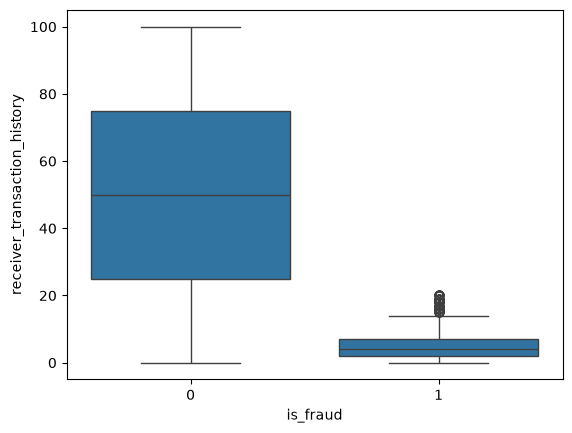

In [130]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(
    data=df,
    x="is_fraud",
    y="receiver_transaction_history"
)

plt.show()

In [131]:
print(df["timestamp"].head(10))
print("\nDtype:", df["timestamp"].nunique())
print("\nUnique values:", df["timestamp"].nunique())

0    18:27.7
1    34:55.5
2    49:42.8
3    16:29.9
4    39:44.7
5    02:41.8
6    17:02.2
7    07:36.1
8    13:49.7
9    00:36.2
Name: timestamp, dtype: object

Dtype: 18748

Unique values: 18748


In [132]:
df.groupby("is_fraud")["receiver_account_age"].describe()

,count,mean,std,min,25%,50%,75%,max
is_fraud,,,,,,,,
0,21848.0,181.552728,160.477517,0.0,50.0,136.0,276.25,723.0
1,4545.0,0.000000,0.000000,0.0,0.0,0.0,0.00,0.0


In [133]:
leakage_candidates = [
    "receiver_account_age"    
]
leakage_candidates

['receiver_account_age']

In [134]:
df.groupby("is_fraud")["receiver_transaction_history"].agg(
    ["min", "max", "mean", "median"]
)

,min,max,mean,median
is_fraud,,,,
0,0,100,50.124359,50.0
1,0,20,4.877228,4.0


In [135]:
numeric_audit = []

for col in numeric_features:
    legit = df.loc[df["is_fraud"] == 0, col]
    fraud = df.loc[df["is_fraud"] == 1, col]

    numeric_audit.append({
        "feature": col,
        "legit_mean": legit.mean(),
        "fraud_mean": fraud.mean(),
        "legit_median": legit.median(),
        "fraud_median": fraud.median(),
        "legit_min": legit.min(),
        "fraud_min": fraud.min(),
        "legit_max": legit.max(),
        "fraud_max": fraud.max()
    })

numeric_audit_df = pd.DataFrame(numeric_audit)

numeric_audit_df

,feature,legit_mean,fraud_mean,legit_median,fraud_median,legit_min,fraud_min,legit_max,fraud_max
0,amount,3620.345820,10850.235157,3460.913626,6482.957050,139.267664,519.437400,10523.910200,49970.158580
1,session_duration,165.079183,145.020682,165.000000,110.000000,30.000000,5.000000,300.000000,600.000000
2,authentication_attempts,1.000000,1.630583,1.000000,1.000000,1.000000,1.000000,1.000000,5.000000
3,receiver_account_age,181.552728,0.000000,136.000000,0.000000,0.000000,0.000000,723.000000,0.000000
4,receiver_transaction_history,50.124359,4.877228,50.000000,4.000000,0.000000,0.000000,100.000000,20.000000
5,transaction_amount_vs_sender_history,2.357681,6.305597,1.380621,2.457720,0.222799,0.237345,55.099714,294.628680
6,geographic_disparity,9983.800605,10108.966753,9964.526653,10222.902930,14.167439,72.278504,19983.477890,19943.796130
7,transaction_time_of_day,11.464894,8.808361,11.000000,6.000000,0.000000,0.000000,23.000000,23.000000
8,time_between_link_click_and_transaction,0.000000,2.902090,0.000000,0.000000,0.000000,0.000000,0.000000,30.000000
9,unusual_device_flag,0.000000,0.327833,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000


In [136]:
numeric_quantile_audit = []

for col in numeric_features:
    if col in ["receiver_account_age"]:
        continue

    try:
        bins = pd.qcut(
            df[col],
            q=10,
            duplicates="drop"
        )

        temp = pd.DataFrame({
            "bin": bins,
            "is_fraud": df["is_fraud"]
        })

        fraud_rates = temp.groupby(
            "bin",
            observed=True
        )["is_fraud"].mean()

        numeric_quantile_audit.append({
            "feature": col,
            "min_fraud_rate": fraud_rates.min(),
            "max_fraud_rate": fraud_rates.max(),
            "fraud_rate_range": fraud_rates.max() - fraud_rates.min()
        })

    except Exception:
        pass

quantile_audit_df = pd.DataFrame(numeric_quantile_audit)

quantile_audit_df.sort_values(
    "fraud_rate_range",
    ascending=False
)

,feature,min_fraud_rate,max_fraud_rate,fraud_rate_range
13,app_switching_frequency,0.116240,1.000000,0.883760
0,amount,0.076515,0.779924,0.703409
3,receiver_transaction_history,0.000000,0.700275,0.700275
14,keyboard_input_speed,0.090944,0.728409,0.637466
12,input_timing_consistency,0.094354,0.728788,0.634434
27,request_amount_roundness,0.016294,0.560606,0.544312
15,input_pause_patterns,0.097385,0.596970,0.499584
18,background_data_usage,0.095870,0.586742,0.490873
21,pin_entry_speed,0.113258,0.599242,0.485985
6,transaction_time_of_day,0.024828,0.378992,0.354164


In [137]:
df.groupby("app_switching_frequency")["is_fraud"].agg(
    ["count", "sum", "mean"]
).sort_index()

,count,sum,mean
app_switching_frequency,,,
0,8608,1314,0.152649
1,8539,1375,0.161026
2,8362,972,0.116240
3,192,192,1.000000
5,68,68,1.000000
6,69,69,1.000000
7,76,76,1.000000
8,71,71,1.000000
9,59,59,1.000000


In [138]:
categorical_cols = df.select_dtypes(include="object").columns.tolist()

categorical_cols

['transaction_id',
 'user_id',
 'merchant_id',
 'timestamp',
 'description',
 'device_id',
 'ip_address',
 'location',
 'merchant_category_code',
 'session_source',
 'url_referrer',
 'recent_app_installs',
 'permissions_granted',
 'recognized_screen_sharing_apps',
 'pin_entry_method',
 'authorization_method',
 'transaction_type',
 'request_description',
 'request_description_keywords',
 'relationship_to_requester',
 'handle_typo_analysis',
 'business_name_match',
 'social_media_presence',
 'handle_registration_pattern',
 'handle_verification_status']

In [139]:
categorical_audit = []

for col in categorical_cols:
    if col in [
        "transaction_id",
        "user_id",
        "merchant_id",
        "device_id",
        "ip_address",
        "timestamp"
    ]:
        continue

    grouped = (
        df.groupby(col, dropna=False)["is_fraud"]
        .agg(["count", "sum", "mean"])
        .reset_index()
    )

    for _, row in grouped.iterrows():
        categorical_audit.append({
            "feature": col,
            "value": row[col],
            "rows": int(row["count"]),
            "fraud_count": int(row["sum"]),
            "fraud_rate": row["mean"]
        })

categorical_audit_df = pd.DataFrame(categorical_audit)

categorical_audit_df.sort_values(
    ["fraud_rate", "rows"],
    ascending=[False, False]
)

,feature,value,rows,fraud_count,fraud_rate
23546,handle_verification_status,unverified,4545,4545,1.0
22149,merchant_category_code,unknown,2914,2914,1.0
23545,handle_registration_pattern,recent,1631,1631,1.0
22918,pin_entry_method,pasted,1425,1425,1.0
22152,session_source,link,757,757,1.0
...,...,...,...,...,...
22130,location,"(9.8273895, -151.321637)",1,0,0.0
22133,location,"(9.844946, 128.868587)",1,0,0.0
22141,location,"(9.985207, -2.465108)",1,0,0.0
22143,location,"(9.9929795, 98.201474)",1,0,0.0


In [140]:
categorical_audit_df[
    (categorical_audit_df["rows"] >= 50) &
    (categorical_audit_df["fraud_rate"] >= 0.50)
].sort_values(
    ["fraud_rate", "rows"],
    ascending=[False, False]
)

,feature,value,rows,fraud_count,fraud_rate
23546,handle_verification_status,unverified,4545,4545,1.0
22149,merchant_category_code,unknown,2914,2914,1.0
23545,handle_registration_pattern,recent,1631,1631,1.0
22918,pin_entry_method,pasted,1425,1425,1.0
22152,session_source,link,757,757,1.0
22929,handle_typo_analysis,typo_squatting,747,747,1.0
0,description,OTP authentication payment,733,733,1.0
22919,authorization_method,otp,733,733,1.0
6914,description,Urgent refund processing - act now!,732,732,1.0
22921,transaction_type,collection_request,732,732,1.0


In [141]:
X = df.drop(columns=["is_fraud"])
y=df["is_fraud"]

print("Xshape:", X.shape)
print("y shape:", y.shape)

Xshape: (26393, 66)
y shape: (26393,)


In [142]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

print("\nTraining target:")
print(y_train.value_counts())
print(y_train.value_counts(normalize=True))

print("\nTesting target:")
print(y_test.value_counts())
print(y_test.value_counts(normalize=True))

X_train: (21114, 66)
X_test : (5279, 66)

Training target:
is_fraud
0    17478
1     3636
Name: count, dtype: int64
is_fraud
0    0.827792
1    0.172208
Name: proportion, dtype: float64

Testing target:
is_fraud
0    4370
1     909
Name: count, dtype: int64
is_fraud
0    0.827808
1    0.172192
Name: proportion, dtype: float64


In [143]:
for col in ["user_id", "merchant_id", "device_id"]:
    print(f"\n---{col}---")
    print("Unique in train:", X_train[col].nunique())
    print("Unique in test :", X_test[col].nunique())
    print("Most common:")
    print(X_train[col].value_counts().head())
    


---user_id---
Unique in train: 4779
Unique in test : 3181
Most common:
user_id
johnsonandrew    20
smiller          19
ymorgan          18
vhall            17
owilliams        16
Name: count, dtype: int64

---merchant_id---
Unique in train: 5635
Unique in test : 2687
Most common:
merchant_id
da2aec1a-42d5-4b13-bbe7-3a5ce249005b    18
8ec7d3e8-9ad3-4b21-9d87-f811f44ea6db    18
2abf2d5e-8f95-447c-b189-e6b923eb13d6    18
633b02f4-b945-419d-8593-52965a78b0d1    18
66d43ef0-a34b-4a63-ab0a-c302bd586ccc    17
Name: count, dtype: int64

---device_id---
Unique in train: 6089
Unique in test : 3460
Most common:
device_id
066ee55b-a60b-4df2-8d2b-974a311fe621    13
c4677837-901c-45ec-8205-051fb9adaf7e    12
d2121638-ec89-4fb4-aa82-3d7464127e40    12
8e8aa064-a7b3-4884-b443-098fa7a6cfb5    12
3bc5984c-bcea-42fb-a66f-0a32e62fd5a1    12
Name: count, dtype: int64


In [144]:
id_columns = ["user_id", "merchant_id", "device_id"]

frequency_maps = {}

for col in id_columns:
    frequency_maps[col] = X_train[col].value_counts()

    print(f"\n--- {col} ---")
    print("Unique training IDs:", len(frequency_maps[col]))
    print("Most common frequency:", frequency_maps[col].max())


--- user_id ---
Unique training IDs: 4779
Most common frequency: 20

--- merchant_id ---
Unique training IDs: 5635
Most common frequency: 18

--- device_id ---
Unique training IDs: 6089
Most common frequency: 13


In [145]:
for col in id_columns:
    new_col = f"{col}_frequency"

    X_train[new_col] = X_train[col].map(frequency_maps[col])
    X_test[new_col] = X_test[col].map(frequency_maps[col])

    # IDs never seen during training become 0
    X_train[new_col] = X_train[new_col].fillna(0)
    X_test[new_col] = X_test[new_col].fillna(0)

    print(f"\n--- {new_col} ---")
    print("Train:")
    print(X_train[new_col].describe())
    print("Test:")
    print(X_test[new_col].describe())


--- user_id_frequency ---
Train:
count    21114.000000
mean         5.495406
std          2.454763
min          1.000000
25%          4.000000
50%          5.000000
75%          7.000000
max         20.000000
Name: user_id_frequency, dtype: float64
Test:
count    5279.000000
mean        4.578519
std         2.464880
min         0.000000
25%         3.000000
50%         4.000000
75%         6.000000
max        20.000000
Name: user_id_frequency, dtype: float64

--- merchant_id_frequency ---
Train:
count    21114.000000
mean         8.212560
std          4.203679
min          1.000000
25%          6.000000
50%          9.000000
75%         11.000000
max         18.000000
Name: merchant_id_frequency, dtype: float64
Test:
count    5279.000000
mean        7.221254
std         4.215707
min         0.000000
25%         5.000000
50%         8.000000
75%        10.000000
max        18.000000
Name: merchant_id_frequency, dtype: float64

--- device_id_frequency ---
Train:
count    21114.000000
me

In [146]:
for col in id_columns:
    freq_col = f"{col}_frequency"
    unseen = (X_test[freq_col] ==0).sum()
    print(
        f"{col}: "
        f"{unseen} unseen test IDs "
        f"({unseen / len(X_test) * 100:2f}%)"
    )

user_id: 67 unseen test IDs (1.269180%)
merchant_id: 909 unseen test IDs (17.219170%)
device_id: 395 unseen test IDs (7.482478%)


In [147]:
for col in id_columns:
    freq_col = f"{col}_frequency"

    print(f"\n--- {freq_col} ---")
    print(
        X_train.assign(target=y_train)
        .groupby("target")[freq_col]
        .agg(["mean", "median", "min", "max"])
    )


--- user_id_frequency ---
            mean  median  min  max
target                            
0       5.485925     5.0    1   20
1       5.540979     5.0    1   20

--- merchant_id_frequency ---
            mean  median  min  max
target                            
0       9.713011    10.0    2   18
1       1.000000     1.0    1    1

--- device_id_frequency ---
            mean  median  min  max
target                            
0       4.961437     5.0    1   13
1       3.679868     4.0    1   13


In [148]:
print(
    X_train.assign(target=y_train)
    .groupby("merchant_id_frequency")["target"]
    .agg(["count", "sum", "mean"])
    .sort_index()
)


                       count   sum  mean
merchant_id_frequency                   
1                       3636  3636   1.0
2                         28     0   0.0
3                        117     0   0.0
4                        324     0   0.0
5                        550     0   0.0
6                       1386     0   0.0
7                       1645     0   0.0
8                       2056     0   0.0
9                       2277     0   0.0
10                      2420     0   0.0
11                      2222     0   0.0
12                      1608     0   0.0
13                      1157     0   0.0
14                       532     0   0.0
15                       630     0   0.0
16                       352     0   0.0
17                       102     0   0.0
18                        72     0   0.0


In [149]:
print(
    X_train.assign(target=y_train)
    .groupby("device_id_frequency")["target"]
    .agg(["count", "sum", "mean"])
    .sort_index()
)

                     count   sum      mean
device_id_frequency                       
1                     1541  1230  0.798183
2                     1440   181  0.125694
3                     2979   359  0.120510
4                     3888   454  0.116770
5                     4165   498  0.119568
6                     3024   398  0.131614
7                     2058   276  0.134111
8                     1064   142  0.133459
9                      531    56  0.105461
10                     230    24  0.104348
11                     121    12  0.099174
12                      60     5  0.083333
13                      13     1  0.076923


In [150]:
numeric_candidates = [
    "amount",
    "session_duration",
    "receiver_transaction_history",
    "transaction_amount_vs_sender_history",
    "transaction_time_of_day",
    "input_timing_consistency",
    "keyboard_input_speed",
    "input_pause_patterns",
    "screen_active_time",
    "geographic_location_vs_ip",
    "background_data_usage",
    "pin_entry_speed",
    "request_amount_roundness"
]

categorical_candidates = [
    "session_source"
]

print("Numeric candidates:", len(numeric_candidates))
print("Categorical candidates:", len(categorical_candidates))

print("\nMissing numeric candidates:")
print([c for c in numeric_candidates if c not in X_train.columns])

print("\nMissing categorical candidates:")
print([c for c in categorical_candidates if c not in X_train.columns])

Numeric candidates: 13
Categorical candidates: 1

Missing numeric candidates:
[]

Missing categorical candidates:
[]


In [151]:
caterogical_candidates = []

print("Numeric candidates:", len(numeric_candidates))
print("Caterogical candidates:", len(caterogical_candidates))

Numeric candidates: 13
Caterogical candidates: 0


In [152]:
print("X_train exists:", "X_train" in globals())
print("X_test exists:", "X_test" in globals())
print("numeric_candidates exists:", "numeric_candidates" in globals())

X_train exists: True
X_test exists: True
numeric_candidates exists: True


In [153]:
print("Candidates:")
print(numeric_candidates)

print("\nMissing from X_train:")
print([c for c in numeric_candidates if c not in X_train.columns])

print("\nX_train shape:", X_train.shape)
print("X_train columns:", len(X_train.columns))

Candidates:
['amount', 'session_duration', 'receiver_transaction_history', 'transaction_amount_vs_sender_history', 'transaction_time_of_day', 'input_timing_consistency', 'keyboard_input_speed', 'input_pause_patterns', 'screen_active_time', 'geographic_location_vs_ip', 'background_data_usage', 'pin_entry_speed', 'request_amount_roundness']

Missing from X_train:
[]

X_train shape: (21114, 69)
X_train columns: 69


In [154]:
X_train_clean = X_train[numeric_candidates].copy()
X_test_clean = X_test[numeric_candidates].copy()

print("X_train_clean:", X_train_clean.shape)
print("X_test_clean:", X_test_clean.shape)

X_train_clean: (21114, 13)
X_test_clean: (5279, 13)


In [155]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

baseline_lr = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

baseline_lr.fit(X_train_clean, y_train)

print("Baseline Logistic Regression trained successfully.")

Baseline Logistic Regression trained successfully.


c:\Users\user\AppData\Local\Python\pythoncore-3.12-64\Lib\site-packages\sklearn\linear_model\_logistic.py:455: OptimizeWarning: Unknown solver options: iprint
  opt_res = optimize.minimize(


In [156]:
y_prob = baseline_lr.predict_proba(X_test_clean)[:, 1]

print("First 10 fraud probabilities:")
print(y_prob[:10])

print("\nProbability range:")
print("Min:", y_prob.min())
print("Max:", y_prob.max())
print("Mean:", y_prob.mean())

First 10 fraud probabilities:
[2.46805645e-01 9.94761497e-01 8.33796893e-01 1.54306794e-07
 1.19539977e-05 1.41525620e-04 9.99999992e-01 2.84160008e-09
 9.99876596e-01 2.40950969e-01]

Probability range:
Min: 1.3972694391056364e-10
Max: 0.9999999999371039
Mean: 0.17275055174420137


In [157]:
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

# Convert probabilities into class predictions
y_pred = (y_prob >= 0.5).astype(int)

print("ROC-AUC:", roc_auc_score(y_test, y_prob))
print("PR-AUC:", average_precision_score(y_test, y_prob))

print("\nAt threshold = 0.5")
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

ROC-AUC: 0.9882396477634033
PR-AUC: 0.9549258463573388

At threshold = 0.5
Precision: 0.9055023923444976
Recall: 0.8327832783278328
F1 Score: 0.867621776504298

Confusion Matrix:
[[4291   79]
 [ 152  757]]


In [158]:
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = np.arange(0.1, 1.0, 0.1)

for threshold in thresholds:
    y_pred_threshold = (y_prob >= threshold).astype(int)

    precision = precision_score(y_test, y_pred_threshold)
    recall = recall_score(y_test, y_pred_threshold)
    f1 = f1_score(y_test, y_pred_threshold)

    print(
        f"Threshold: {threshold:.1f} | "
        f"Precision: {precision:.4f} | "
        f"Recall: {recall:.4f} | "
        f"F1: {f1:.4f}"
    )

Threshold: 0.1 | Precision: 0.6612 | Recall: 0.9703 | F1: 0.7864


Threshold: 0.2 | Precision: 0.7487 | Recall: 0.9307 | F1: 0.8298
Threshold: 0.3 | Precision: 0.8154 | Recall: 0.8944 | F1: 0.8531
Threshold: 0.4 | Precision: 0.8653 | Recall: 0.8625 | F1: 0.8639
Threshold: 0.5 | Precision: 0.9055 | Recall: 0.8328 | F1: 0.8676
Threshold: 0.6 | Precision: 0.9381 | Recall: 0.8009 | F1: 0.8641
Threshold: 0.7 | Precision: 0.9643 | Recall: 0.7734 | F1: 0.8584
Threshold: 0.8 | Precision: 0.9822 | Recall: 0.7283 | F1: 0.8364
Threshold: 0.9 | Precision: 0.9967 | Recall: 0.6656 | F1: 0.7982


In [159]:
import pandas as pd

coefficients = baseline_lr.named_steps["model"].coef_[0]

feature_importance = pd.DataFrame({
    "feature": numeric_candidates,
    "coefficient": coefficients,
    "absolute_coefficient": abs(coefficients)
})

feature_importance = feature_importance.sort_values(
    "absolute_coefficient",
    ascending=False
)

print(feature_importance)

                                 feature  coefficient  absolute_coefficient
2           receiver_transaction_history    -6.336202              6.336202
0                                 amount     2.428580              2.428580
5               input_timing_consistency    -0.609955              0.609955
7                   input_pause_patterns     0.558456              0.558456
1                       session_duration    -0.494703              0.494703
10                 background_data_usage     0.417429              0.417429
4                transaction_time_of_day    -0.401764              0.401764
12              request_amount_roundness     0.311886              0.311886
11                       pin_entry_speed    -0.293854              0.293854
6                   keyboard_input_speed    -0.274821              0.274821
3   transaction_amount_vs_sender_history     0.165921              0.165921
8                     screen_active_time    -0.069430              0.069430
9           

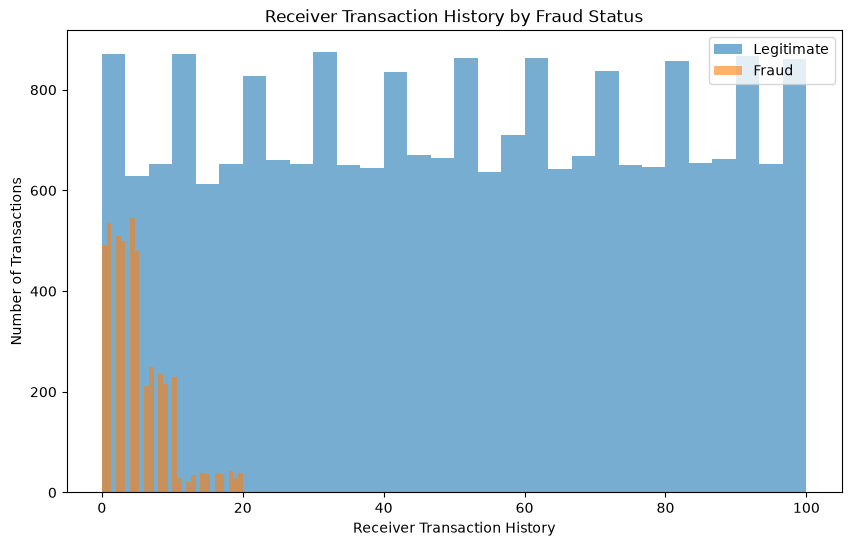

In [160]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.hist(
    df.loc[df["is_fraud"] == 0, "receiver_transaction_history"],
    bins=30,
    alpha=0.6,
    label="Legitimate"
)

plt.hist(
    df.loc[df["is_fraud"] == 1, "receiver_transaction_history"],
    bins=30,
    alpha=0.6,
    label="Fraud"
)

plt.xlabel("Receiver Transaction History")
plt.ylabel("Number of Transactions")
plt.title("Receiver Transaction History by Fraud Status")
plt.legend()
plt.show()

In [161]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, average_precision_score

single_feature_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000, random_state=42))
])

single_feature_model.fit(
    X_train_clean[["receiver_transaction_history"]],
    y_train
)

single_prob = single_feature_model.predict_proba(
    X_test_clean[["receiver_transaction_history"]]
)[:, 1]

print("ROC-AUC:", roc_auc_score(y_test, single_prob))
print("PR-AUC:", average_precision_score(y_test, single_prob))

ROC-AUC: 0.9481057716755658
PR-AUC: 0.6890984844385631


c:\Users\user\AppData\Local\Python\pythoncore-3.12-64\Lib\site-packages\sklearn\linear_model\_logistic.py:455: OptimizeWarning: Unknown solver options: iprint
  opt_res = optimize.minimize(


In [162]:
from sklearn.inspection import permutation_importance

result = permutation_importance(
    baseline_lr,
    X_test_clean,
    y_test,
    scoring="roc_auc",
    n_repeats=10,
    random_state=42
)

permutation_importance_df = pd.DataFrame({
    "feature": numeric_candidates,
    "importance_mean": result.importances_mean,
    "importance_std": result.importances_std
}).sort_values(
    "importance_mean",
    ascending=False
)

print(permutation_importance_df)

                                 feature  importance_mean  importance_std
2           receiver_transaction_history         0.277899        0.008488
0                                 amount         0.029111        0.001339
5               input_timing_consistency         0.002343        0.000250
7                   input_pause_patterns         0.001900        0.000283
1                       session_duration         0.001390        0.000399
4                transaction_time_of_day         0.001167        0.000291
10                 background_data_usage         0.000643        0.000220
12              request_amount_roundness         0.000429        0.000145
11                       pin_entry_speed         0.000306        0.000177
6                   keyboard_input_speed         0.000295        0.000144
3   transaction_amount_vs_sender_history         0.000218        0.000071
8                     screen_active_time         0.000045        0.000044
9              geographic_location_vs_

In [163]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, average_precision_score

features_without_history = [
    feature for feature in numeric_candidates
    if feature != "receiver_transaction_history"
]

X_train_no_history = X_train_clean[features_without_history]
X_test_no_history = X_test_clean[features_without_history]

lr_no_history = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

lr_no_history.fit(X_train_no_history, y_train)

prob_no_history = lr_no_history.predict_proba(
    X_test_no_history
)[:, 1]

print("ROC-AUC:", roc_auc_score(y_test, prob_no_history))
print("PR-AUC:", average_precision_score(y_test, prob_no_history))

ROC-AUC: 0.914579100930688
PR-AUC: 0.8605316620071739


c:\Users\user\AppData\Local\Python\pythoncore-3.12-64\Lib\site-packages\sklearn\linear_model\_logistic.py:455: OptimizeWarning: Unknown solver options: iprint
  opt_res = optimize.minimize(


In [164]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, average_precision_score

rf_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_clean, y_train)

rf_prob = rf_model.predict_proba(X_test_clean)[:, 1]

print("Random Forest Results")
print("ROC-AUC:", roc_auc_score(y_test, rf_prob))
print("PR-AUC:", average_precision_score(y_test, rf_prob))

Random Forest Results
ROC-AUC: 0.9963681265151687
PR-AUC: 0.9856712204589302


In [165]:
rf_importance = pd.DataFrame({
    "feature": numeric_candidates,
    "importance": rf_model.feature_importances_
}).sort_values(
    "importance",
    ascending=False
)

print(rf_importance)

                                 feature  importance
2           receiver_transaction_history    0.262389
0                                 amount    0.164890
12              request_amount_roundness    0.117593
5               input_timing_consistency    0.111671
6                   keyboard_input_speed    0.103410
3   transaction_amount_vs_sender_history    0.046714
10                 background_data_usage    0.045176
7                   input_pause_patterns    0.044369
11                       pin_entry_speed    0.037672
4                transaction_time_of_day    0.024716
1                       session_duration    0.020447
8                     screen_active_time    0.011618
9              geographic_location_vs_ip    0.009336


In [166]:
from sklearn.inspection import permutation_importance

rf_perm = permutation_importance(
    rf_model,
    X_test_clean,
    y_test,
    scoring="roc_auc",
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

rf_perm_df = pd.DataFrame({
    "feature": numeric_candidates,
    "importance_mean": rf_perm.importances_mean,
    "importance_std": rf_perm.importances_std
}).sort_values(
    "importance_mean",
    ascending=False
)

print(rf_perm_df)

                                 feature  importance_mean  importance_std
2           receiver_transaction_history         0.075911        0.002525
12              request_amount_roundness         0.012288        0.000448
0                                 amount         0.008929        0.000547
5               input_timing_consistency         0.004600        0.000310
6                   keyboard_input_speed         0.004314        0.000255
11                       pin_entry_speed         0.001733        0.000204
4                transaction_time_of_day         0.001575        0.000256
7                   input_pause_patterns         0.001569        0.000162
10                 background_data_usage         0.001424        0.000138
3   transaction_amount_vs_sender_history         0.000558        0.000092
1                       session_duration         0.000101        0.000075
9              geographic_location_vs_ip         0.000059        0.000029
8                     screen_active_ti

In [167]:
from sklearn.model_selection import train_test_split

X_train_final, X_val, y_train_final, y_val = train_test_split(
    X_train_clean,
    y_train,
    test_size=0.20,
    random_state=42,
    stratify=y_train
)

print("Training:", X_train_final.shape)
print("Validation:", X_val.shape)

print("\nTraining fraud rate:", y_train_final.mean())
print("Validation fraud rate:", y_val.mean())

Training: (16891, 13)
Validation: (4223, 13)

Training fraud rate: 0.17222189331596707
Validation fraud rate: 0.17215249822401138


In [168]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, average_precision_score

lr_final = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

lr_final.fit(X_train_final, y_train_final)

lr_val_prob = lr_final.predict_proba(X_val)[:, 1]

print("Logistic Regression - Validation")
print("ROC-AUC:", roc_auc_score(y_val, lr_val_prob))
print("PR-AUC:", average_precision_score(y_val, lr_val_prob))

Logistic Regression - Validation
ROC-AUC: 0.9871053261105637
PR-AUC: 0.9515259806145199


c:\Users\user\AppData\Local\Python\pythoncore-3.12-64\Lib\site-packages\sklearn\linear_model\_logistic.py:455: OptimizeWarning: Unknown solver options: iprint
  opt_res = optimize.minimize(


In [169]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, average_precision_score

rf_final = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

rf_final.fit(X_train_final, y_train_final)

rf_val_prob = rf_final.predict_proba(X_val)[:, 1]

print("Random Forest - Validation")
print("ROC-AUC:", roc_auc_score(y_val, rf_val_prob))
print("PR-AUC:", average_precision_score(y_val, rf_val_prob))

Random Forest - Validation
ROC-AUC: 0.996341663020658
PR-AUC: 0.9855892733257218


In [170]:
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = np.arange(0.1, 1.0, 0.1)

for threshold in thresholds:
    y_val_pred = (rf_val_prob >= threshold).astype(int)

    precision = precision_score(y_val, y_val_pred)
    recall = recall_score(y_val, y_val_pred)
    f1 = f1_score(y_val, y_val_pred)

    print(
        f"Threshold: {threshold:.1f} | "
        f"Precision: {precision:.4f} | "
        f"Recall: {recall:.4f} | "
        f"F1: {f1:.4f}"
    )

Threshold: 0.1 | Precision: 0.7018 | Recall: 0.9904 | F1: 0.8214
Threshold: 0.2 | Precision: 0.8090 | Recall: 0.9670 | F1: 0.8810
Threshold: 0.3 | Precision: 0.8944 | Recall: 0.9436 | F1: 0.9183
Threshold: 0.4 | Precision: 0.9501 | Recall: 0.9175 | F1: 0.9335
Threshold: 0.5 | Precision: 0.9764 | Recall: 0.9106 | F1: 0.9423
Threshold: 0.6 | Precision: 0.9894 | Recall: 0.9023 | F1: 0.9439
Threshold: 0.7 | Precision: 0.9969 | Recall: 0.8900 | F1: 0.9404
Threshold: 0.8 | Precision: 0.9984 | Recall: 0.8721 | F1: 0.9310
Threshold: 0.9 | Precision: 1.0000 | Recall: 0.8363 | F1: 0.9109


In [171]:
from sklearn.ensemble import RandomForestClassifier

rf_final = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

rf_final.fit(X_train_final, y_train_final)

print("Random Forest final training completed.")

Random Forest final training completed.


In [172]:
rf_test_prob = rf_final.predict_proba(X_test_clean)[:, 1]

print("First 10 test probabilities:")
print(rf_test_prob[:10])

print("Number of test predictions:", len(rf_test_prob))

First 10 test probabilities:
[0.         1.         1.         0.00333333 0.         0.
 0.99333333 0.         1.         0.92      ]
Number of test predictions: 5279


In [173]:
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

rf_test_pred = (rf_test_prob >= 0.6).astype(int)

print("FINAL TEST RESULTS")
print("------------------")

print("ROC-AUC:", roc_auc_score(y_test, rf_test_prob))
print("PR-AUC:", average_precision_score(y_test, rf_test_prob))

print("\nThreshold: 0.6")
print("Precision:", precision_score(y_test, rf_test_pred))
print("Recall:", recall_score(y_test, rf_test_pred))
print("F1:", f1_score(y_test, rf_test_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, rf_test_pred))

FINAL TEST RESULTS
------------------
ROC-AUC: 0.9966143296251823
PR-AUC: 0.9864973747507171

Threshold: 0.6
Precision: 0.9927095990279465
Recall: 0.8987898789878987
F1: 0.9434180138568129

Confusion Matrix:
[[4364    6]
 [  92  817]]


In [174]:
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.ensemble import RandomForestClassifier

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

rf_cv = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

cv_results = cross_validate(
    rf_cv,
    X_train_final,
    y_train_final,
    cv=cv,
    scoring={
        "roc_auc": "roc_auc",
        "pr_auc": "average_precision"
    },
    n_jobs=-1
)

print("ROC-AUC scores:")
print(cv_results["test_roc_auc"])

print("\nPR-AUC scores:")
print(cv_results["test_pr_auc"])

print("\nMean ROC-AUC:", cv_results["test_roc_auc"].mean())
print("Std ROC-AUC:", cv_results["test_roc_auc"].std())

print("\nMean PR-AUC:", cv_results["test_pr_auc"].mean())
print("Std PR-AUC:", cv_results["test_pr_auc"].std())

ROC-AUC scores:
[0.99727617 0.99494399 0.99662718 0.99625017 0.99683027]

PR-AUC scores:
[0.98899486 0.98039406 0.98711964 0.98459857 0.9871664 ]

Mean ROC-AUC: 0.9963855537742891
Std ROC-AUC: 0.0007931928367133165

Mean PR-AUC: 0.985654704269834
Std PR-AUC: 0.002979182963782458


In [175]:
history_check = pd.DataFrame({
    "feature": ["receiver_transaction_history"],
    "legit_mean": [
        df.loc[df["is_fraud"] == 0, "receiver_transaction_history"].mean()
    ],
    "fraud_mean": [
        df.loc[df["is_fraud"] == 1, "receiver_transaction_history"].mean()
    ],
    "legit_median": [
        df.loc[df["is_fraud"] == 0, "receiver_transaction_history"].median()
    ],
    "fraud_median": [
        df.loc[df["is_fraud"] == 1, "receiver_transaction_history"].median()
    ]
})

print(history_check)

                        feature  legit_mean  fraud_mean  legit_median  \
0  receiver_transaction_history   50.124359    4.877228          50.0   

   fraud_median  
0           4.0  


In [176]:
history_audit = (
    df.groupby("receiver_transaction_history")["is_fraud"]
      .agg(
          rows="size",
          fraud_count="sum",
          fraud_rate="mean"
      )
      .reset_index()
)

print(history_audit.to_string(index=False))

 receiver_transaction_history  rows  fraud_count  fraud_rate
                            0   707          491    0.694484
                            1   730          535    0.732877
                            2   750          510    0.680000
                            3   719          499    0.694019
                            4   744          545    0.732527
                            5   681          480    0.704846
                            6   441          212    0.480726
                            7   483          250    0.517598
                            8   437          236    0.540046
                            9   435          216    0.496552
                           10   447          229    0.512304
                           11   246           28    0.113821
                           12   241           21    0.087137
                           13   251           35    0.139442
                           14   255           38    0.149020
                        

In [177]:
fraud_history_max = df.loc[
    df["is_fraud"] == 1,
    "receiver_transaction_history"
].max()

legit_history_min = df.loc[
    df["is_fraud"] == 0,
    "receiver_transaction_history"
].min()

print("Maximum history among fraud:", fraud_history_max)
print("Minimum history among legitimate:", legit_history_min)

Maximum history among fraud: 20
Minimum history among legitimate: 0


In [178]:
clean_features_no_history = [
    col for col in numeric_candidates
    if col != "receiver_transaction_history"
]

print("Features:", len(clean_features_no_history))
print(clean_features_no_history)


Features: 12
['amount', 'session_duration', 'transaction_amount_vs_sender_history', 'transaction_time_of_day', 'input_timing_consistency', 'keyboard_input_speed', 'input_pause_patterns', 'screen_active_time', 'geographic_location_vs_ip', 'background_data_usage', 'pin_entry_speed', 'request_amount_roundness']


In [179]:
X_train_no_history = X_train_clean[clean_features_no_history].copy()
X_val_no_history = X_val[clean_features_no_history].copy()
X_test_no_history = X_test_clean[clean_features_no_history].copy()

print(X_train_no_history.shape)
print(X_val_no_history.shape)
print(X_test_no_history.shape)

(21114, 12)
(4223, 12)
(5279, 12)


In [180]:
X_train_no_history = X_train_final[clean_features_no_history].copy()
X_val_no_history = X_val[clean_features_no_history].copy()
X_test_no_history = X_test_clean[clean_features_no_history].copy()

print(X_train_no_history.shape)
print(X_val_no_history.shape)
print(X_test_no_history.shape)

(16891, 12)
(4223, 12)
(5279, 12)


In [181]:
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.ensemble import RandomForestClassifier

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

rf_no_history = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

cv_results_no_history = cross_validate(
    rf_no_history,
    X_train_no_history,
    y_train_final,
    cv=cv,
    scoring={
        "roc_auc": "roc_auc",
        "pr_auc": "average_precision"
    },
    n_jobs=-1
)

print("ROC-AUC per fold:", cv_results_no_history["test_roc_auc"])
print("ROC-AUC mean:", cv_results_no_history["test_roc_auc"].mean())
print("ROC-AUC std:", cv_results_no_history["test_roc_auc"].std())

print("PR-AUC per fold:", cv_results_no_history["test_pr_auc"])
print("PR-AUC mean:", cv_results_no_history["test_pr_auc"].mean())
print("PR-AUC std:", cv_results_no_history["test_pr_auc"].std())

ROC-AUC per fold: [0.97265449 0.95310864 0.96498741 0.95789917 0.96509722]
ROC-AUC mean: 0.9627493873721636
ROC-AUC std: 0.006709706050734062
PR-AUC per fold: [0.95269543 0.92906065 0.95086869 0.93126279 0.94335598]
PR-AUC mean: 0.9414487079978648
PR-AUC std: 0.009757863167954356


In [182]:
rf_clean = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

rf_clean.fit(X_train_no_history, y_train_final)

clean_val_prob = rf_clean.predict_proba(X_val_no_history)[:, 1]

print("Validation ROC-AUC:",
      roc_auc_score(y_val, clean_val_prob))

print("Validation PR-AUC:",
      average_precision_score(y_val, clean_val_prob))

Validation ROC-AUC: 0.9654608214064255
Validation PR-AUC: 0.9431609864273516


In [183]:
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]

for threshold in thresholds:
    pred = (clean_val_prob >= threshold).astype(int)

    precision = precision_score(y_val, pred)
    recall = recall_score(y_val, pred)
    f1 = f1_score(y_val, pred)

    print(
        f"Threshold: {threshold:.1f} | "
        f"Precision: {precision:.4f} | "
        f"Recall: {recall:.4f} | "
        f"F1: {f1:.4f}"
    )

Threshold: 0.1 | Precision: 0.7483 | Recall: 0.9120 | F1: 0.8221
Threshold: 0.2 | Precision: 0.9161 | Recall: 0.9010 | F1: 0.9085
Threshold: 0.3 | Precision: 0.9569 | Recall: 0.8858 | F1: 0.9200
Threshold: 0.4 | Precision: 0.9726 | Recall: 0.8803 | F1: 0.9242
Threshold: 0.5 | Precision: 0.9876 | Recall: 0.8762 | F1: 0.9286
Threshold: 0.6 | Precision: 0.9922 | Recall: 0.8721 | F1: 0.9283
Threshold: 0.7 | Precision: 0.9937 | Recall: 0.8680 | F1: 0.9266
Threshold: 0.8 | Precision: 1.0000 | Recall: 0.8569 | F1: 0.9230
Threshold: 0.9 | Precision: 1.0000 | Recall: 0.8281 | F1: 0.9059


In [184]:
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

clean_test_prob = rf_clean.predict_proba(X_test_no_history)[:, 1]

FINAL_THRESHOLD = 0.5

clean_test_pred = (
    clean_test_prob >= FINAL_THRESHOLD
).astype(int)

print("ROC-AUC:",
      roc_auc_score(y_test, clean_test_prob))

print("PR-AUC:",
      average_precision_score(y_test, clean_test_prob))

print("Precision:",
      precision_score(y_test, clean_test_pred))

print("Recall:",
      recall_score(y_test, clean_test_pred))

print("F1:",
      f1_score(y_test, clean_test_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, clean_test_pred))

ROC-AUC: 0.9662408460525687
PR-AUC: 0.9457269393335388
Precision: 0.9864364981504316
Recall: 0.8800880088008801
F1: 0.9302325581395349

Confusion Matrix:
[[4359   11]
 [ 109  800]]


In [185]:
error_analysis = X_test_no_history.copy()

error_analysis["actual"] = y_test.values
error_analysis["probability"] = clean_test_prob
error_analysis["predicted"] = clean_test_pred

error_analysis["error_type"] = "correct"

error_analysis.loc[
    (error_analysis["actual"] == 1) &
    (error_analysis["predicted"] == 0),
    "error_type"
] = "false_negative"

error_analysis.loc[
    (error_analysis["actual"] == 0) &
    (error_analysis["predicted"] == 1),
    "error_type"
] = "false_positive"

print(error_analysis["error_type"].value_counts())

error_type
correct           5159
false_negative     109
false_positive      11
Name: count, dtype: int64


In [186]:
print(
    error_analysis[
        error_analysis["error_type"] != "correct"
    ][
        ["actual", "predicted", "probability", "error_type"]
    ].sort_values("probability")
)

       actual  predicted  probability      error_type
19562       1          0     0.000000  false_negative
7299        1          0     0.000000  false_negative
19742       1          0     0.003333  false_negative
4750        1          0     0.003333  false_negative
1440        1          0     0.003333  false_negative
...       ...        ...          ...             ...
11117       0          1     0.726667  false_positive
29          0          1     0.726667  false_positive
23837       0          1     0.786667  false_positive
17199       0          1     0.810000  false_positive
21867       0          1     0.810000  false_positive

[120 rows x 4 columns]


In [187]:
errors_only = error_analysis[
    error_analysis["error_type"] != "correct"
].copy()

print(
    errors_only[
        [
            "amount",
            "session_duration",
            "transaction_amount_vs_sender_history",
            "transaction_time_of_day",
            "input_timing_consistency",
            "keyboard_input_speed",
            "input_pause_patterns",
            "screen_active_time",
            "geographic_location_vs_ip",
            "background_data_usage",
            "pin_entry_speed",
            "request_amount_roundness",
            "actual",
            "probability",
            "error_type"
        ]
    ].to_string(index=False)
)

      amount  session_duration  transaction_amount_vs_sender_history  transaction_time_of_day  input_timing_consistency  keyboard_input_speed  input_pause_patterns  screen_active_time  geographic_location_vs_ip  background_data_usage  pin_entry_speed  request_amount_roundness  actual  probability     error_type
 7200.613032               101                              5.674439                       18                  0.994718              0.803605              0.139467                 120               13889.857250               0.198995         0.783460                  1.000054       1     0.120000 false_negative
 5987.233458               169                              1.302849                       20                  0.857124              0.741634              0.045744                 214                7138.090995               0.227577         1.926864                  0.999961       1     0.010000 false_negative
 5556.463108                77                              2

In [188]:
fraud_cases = error_analysis[
    error_analysis["actual"] == 1
].copy()

fraud_cases["result"] = fraud_cases["predicted"].map({
    0: "false_negative",
    1: "true_positive"
})

feature_comparison = (
    fraud_cases
    .groupby("result")[clean_features_no_history]
    .mean()
    .T
)

print(feature_comparison)

result                                false_negative  true_positive
amount                                   4817.921729   11733.610688
session_duration                          181.917431     142.186250
transaction_amount_vs_sender_history        3.258125       6.575601
transaction_time_of_day                     9.963303       8.440000
input_timing_consistency                    0.903270       0.752775
keyboard_input_speed                        0.995270       0.635725
input_pause_patterns                        0.104720       0.246195
screen_active_time                        357.642202     334.090000
geographic_location_vs_ip               10722.247026   10166.774249
background_data_usage                       0.241198       0.544128
pin_entry_speed                             1.234066       0.853040
request_amount_roundness                    1.000012       1.319617


In [189]:
false_positives = error_analysis[
    error_analysis["error_type"] == "false_positive"
].copy()

print(
    false_positives[
        clean_features_no_history +
        ["probability"]
    ].sort_values(
        "probability",
        ascending=False
    ).to_string(index=False)
)

      amount  session_duration  transaction_amount_vs_sender_history  transaction_time_of_day  input_timing_consistency  keyboard_input_speed  input_pause_patterns  screen_active_time  geographic_location_vs_ip  background_data_usage  pin_entry_speed  request_amount_roundness  probability
 8849.746739                46                              3.356034                        7                  0.991536              0.936831              0.174599                 238                9062.045975               0.398748         1.834197                  1.000029     0.810000
 9058.458074                69                              1.883438                        6                  0.848827              0.669235              0.169108                 289               10841.711790               0.261903         0.886374                  0.999949     0.810000
 8230.638842               197                              7.183354                        6                  0.868617           

In [190]:
legit_test = error_analysis[
    error_analysis["actual"] == 0
].copy()

legit_test["result"] = legit_test["predicted"].map({
    0: "true_negative",
    1: "false_positive"
})

fp_comparison = (
    legit_test
    .groupby("result")[clean_features_no_history]
    .mean()
    .T
)

print(fp_comparison)

result                                false_positive  true_negative
amount                                   8928.838538    3616.156624
session_duration                          135.545455     165.576279
transaction_amount_vs_sender_history        2.809668       2.314583
transaction_time_of_day                     9.181818      11.396421
input_timing_consistency                    0.891597       0.901170
keyboard_input_speed                        1.084075       1.002315
input_pause_patterns                        0.104722       0.098269
screen_active_time                        323.090909     360.002065
geographic_location_vs_ip               11238.913953    9889.743769
background_data_usage                       0.242866       0.252068
pin_entry_speed                             1.298672       1.251007
request_amount_roundness                    0.999999       1.000002


In [191]:
from sklearn.inspection import permutation_importance

perm_clean = permutation_importance(
    rf_clean,
    X_val_no_history,
    y_val,
    scoring="roc_auc",
    n_repeats=20,
    random_state=42,
    n_jobs=-1
)

importance_clean = (
    pd.DataFrame({
        "feature": X_val_no_history.columns,
        "importance_mean": perm_clean.importances_mean,
        "importance_std": perm_clean.importances_std
    })
    .sort_values("importance_mean", ascending=False)
)

print(importance_clean.to_string(index=False))

                             feature  importance_mean  importance_std
                              amount         0.070440        0.002410
            request_amount_roundness         0.049307        0.003369
             transaction_time_of_day         0.018467        0.001999
transaction_amount_vs_sender_history         0.006442        0.001609
            input_timing_consistency         0.004931        0.001558
                     pin_entry_speed         0.004391        0.001224
                keyboard_input_speed         0.004058        0.001431
                input_pause_patterns         0.002723        0.001381
               background_data_usage         0.002226        0.001100
                    session_duration         0.001998        0.001226
                  screen_active_time         0.000223        0.001130
           geographic_location_vs_ip        -0.000847        0.000690


In [192]:
print("Model:", type(rf_clean).__name__)
print("Number of trees:", rf_clean.n_estimators)
print("Features:", clean_features_no_history)
print("Number of features:", len(clean_features_no_history))
print("Threshold:", FINAL_THRESHOLD)

Model: RandomForestClassifier
Number of trees: 300
Features: ['amount', 'session_duration', 'transaction_amount_vs_sender_history', 'transaction_time_of_day', 'input_timing_consistency', 'keyboard_input_speed', 'input_pause_patterns', 'screen_active_time', 'geographic_location_vs_ip', 'background_data_usage', 'pin_entry_speed', 'request_amount_roundness']
Number of features: 12
Threshold: 0.5


In [193]:
import os
import joblib

os.makedirs("../models", exist_ok=True)

model_artifact = {
    "model": rf_clean,
    "features": clean_features_no_history,
    "threshold": FINAL_THRESHOLD,
    "model_type": "RandomForestClassifier",
    "n_estimators": 300,
    "random_state": 42
}

joblib.dump(
    model_artifact,
    "../models/upi_fraud_model.joblib"
)

print("Model saved successfully.")

Model saved successfully.


In [194]:
print(os.path.exists("../models/upi_fraud_model.joblib"))

True


In [195]:
import joblib

loaded_artifact = joblib.load(
    "../models/upi_fraud_model.joblib"
)

print("Loaded successfully.")
print("Model:", type(loaded_artifact["model"]).__name__)
print("Features:", loaded_artifact["features"])
print("Threshold:", loaded_artifact["threshold"])

Loaded successfully.
Model: RandomForestClassifier
Features: ['amount', 'session_duration', 'transaction_amount_vs_sender_history', 'transaction_time_of_day', 'input_timing_consistency', 'keyboard_input_speed', 'input_pause_patterns', 'screen_active_time', 'geographic_location_vs_ip', 'background_data_usage', 'pin_entry_speed', 'request_amount_roundness']
Threshold: 0.5


In [196]:
model = loaded_artifact["model"]
features = loaded_artifact["features"]
threshold = loaded_artifact["threshold"]

sample = X_test_no_history.iloc[[0]]

probability = model.predict_proba(sample[features])[0, 1]
prediction = int(probability >= threshold)

print("Fraud probability:", probability)
print("Prediction:", prediction)

Fraud probability: 0.006666666666666667
Prediction: 0
